In [18]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, run_xso_stabilityscan, avg_tail

import cariaco_obs as co
import cariaco_baseline_setups as cbs
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cbs, pu, pp):            # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')

grid: 12 phyto (0.5–200 µm), 12 zoo (5–2000 µm)


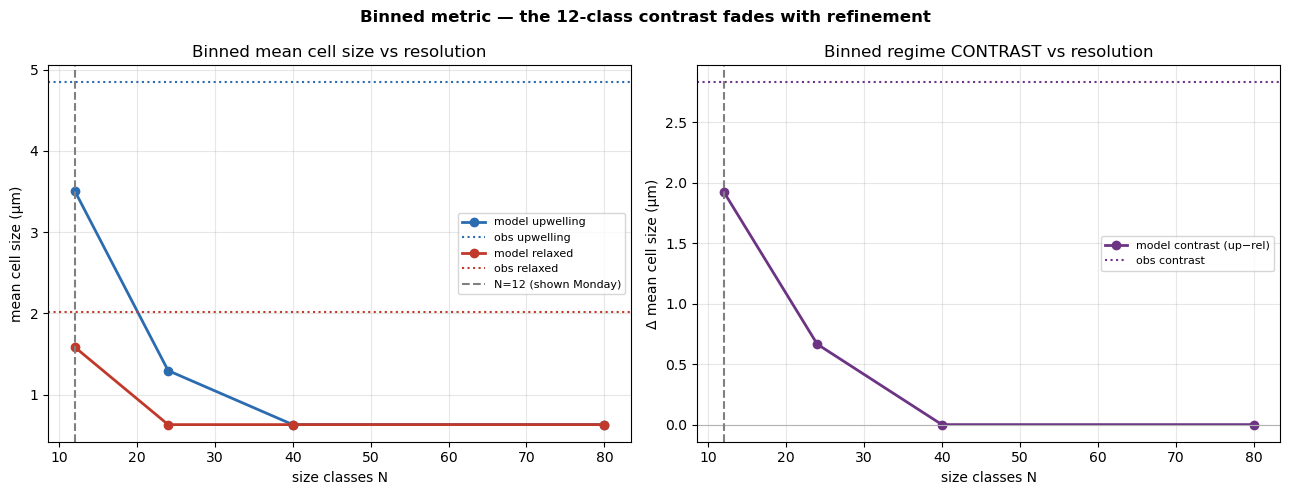

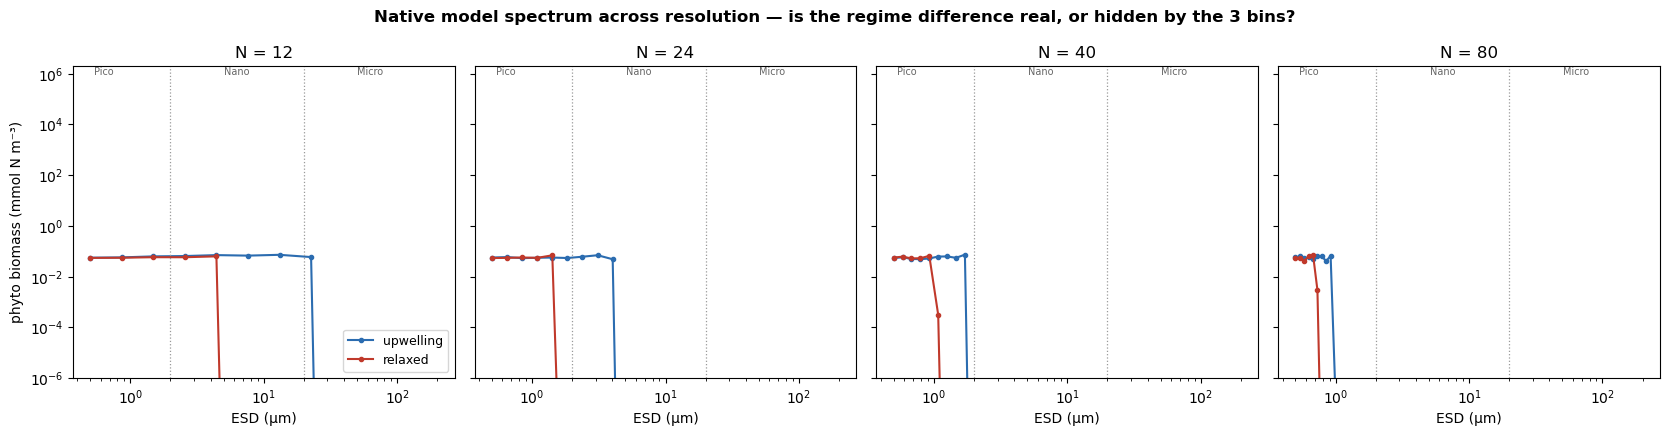

In [19]:
# ── Cell — binned-metric convergence + NATIVE spectrum across resolution ──────
def _setup(N):
    esd = np.logspace(np.log10(0.5), np.log10(200.0), N); z = cbs.ZOO_PHYTO_RATIO*esd
    iv = {
        'Nutrient':{'value_label':'N','value_init':cbs.N_INIT},
        'Phytoplankton':{'biomass_label':'P','biomass_init':np.full(N,cbs.P_INIT),
                         'phyto_esd_index':esd.tolist(),'phyto_esd_label':'phyto_esd'},
        'Zooplankton':{'biomass_label':'Z','biomass_init':np.full(N,cbs.Z_INIT),
                       'zoo_esd_index':z.tolist(),'zoo_esd_label':'zoo_esd'},
        'Inflow':{'var':'N','FN':cbs.FN_DEFAULT,'de':cbs.DE_DEFAULT,'de_label':'de'},
        'Growth':{'resource':'N','consumer':'P','mu_max':mu_taniguchi(esd),'halfsat':ks_t(esd)},
        'Grazing':{'phyto':'P','zoo':'Z','nutrient':'N','Imax':imax_t(z),'KsZ':ksz_t(z),'gamma':cbs.GAMMA_VAL},
        'PhytoLoss':{'population':'P','nutrient':'N','rate':np.full(N,cbs.LAMBDA_VAL)},
        'ZooLoss':{'population':'Z','nutrient':'N','rate':np.full(N,cbs.DELTA_VAL)},
        'PhytoSinking':{'population':'P','w_sink':cbs.W_SINK,'de':'de'},
    }
    return xso.setup(solver='solve_ivp', model=cbs.model_baseline, time=cbs.ivp_time_array,
                     input_vars=iv, solver_kwargs=cbs.IVP_SOLVER_KWARGS), esd

N_list = [12, 24, 40, 80]; COL = {'upwelling':'#2b6cb0','relaxed':'#c0392b'}
mcs = {r: [] for r in regimes}; P_nat = {N: {} for N in N_list}
for N in N_list:
    st, esd = _setup(N)
    for r in regimes:
        out  = pu.run_single_point(cbs.model_baseline, st, {}, fixed_overrides=targets[r]['forcing'])
        Pbar = out['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1)
        proc = pu.process_regime_run(out, esd, cbs.ZOO_PHYTO_RATIO*esd, bin_defs, tail_len=TAIL)
        mcs[r].append(np.nanmedian(proc['mcs_tail'])); P_nat[N][r] = (esd, Pbar)
obs_mcs = {r: np.nanmedian(pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)['mcs']) for r in regimes}

# Fig 1 — binned metric + contrast vs resolution
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for r in regimes:
    ax[0].plot(N_list, mcs[r], 'o-', lw=2, color=COL[r], label=f'model {r}')
    ax[0].axhline(obs_mcs[r], ls=':', color=COL[r], lw=1.5, label=f'obs {r}')
ax[0].axvline(12, ls='--', color='0.5', label='N=12 (shown Monday)')
ax[0].set(title='Binned mean cell size vs resolution', xlabel='size classes N', ylabel='mean cell size (µm)')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
mc = np.array(mcs['upwelling'])-np.array(mcs['relaxed']); oc = obs_mcs['upwelling']-obs_mcs['relaxed']
ax[1].plot(N_list, mc, 'o-', lw=2, color='#6c3483', label='model contrast (up−rel)')
ax[1].axhline(oc, ls=':', color='#6c3483', lw=1.5, label='obs contrast'); ax[1].axhline(0, color='0.7', lw=0.8)
ax[1].axvline(12, ls='--', color='0.5')
ax[1].set(title='Binned regime CONTRAST vs resolution', xlabel='size classes N', ylabel='Δ mean cell size (µm)')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
fig.suptitle('Binned metric — the 12-class contrast fades with refinement', weight='bold'); plt.tight_layout(); plt.show()

# Fig 2 — NATIVE spectrum across resolution, Sieburth bins marked
fig, ax = plt.subplots(1, len(N_list), figsize=(4.2*len(N_list), 4.4), sharey=True)
for a, N in zip(ax, N_list):
    for r in regimes:
        esd, P = P_nat[N][r]; a.plot(esd, P, 'o-', ms=3, color=COL[r], label=r)
    for b in (2.0, 20.0): a.axvline(b, ls=':', color='0.6', lw=0.9)
    a.set(xscale='log', yscale='log', title=f'N = {N}', xlabel='ESD (µm)', ylim=(1e-6, None))
    for xpos, lab in [(0.63,'Pico'), (6.3,'Nano'), (63,'Micro')]:
        a.text(xpos, a.get_ylim()[1], lab, ha='center', va='top', fontsize=7, color='0.4')
ax[0].set_ylabel('phyto biomass (mmol N m⁻³)'); ax[0].legend(fontsize=9)
fig.suptitle('Native model spectrum across resolution — is the regime difference real, or hidden by the 3 bins?',
             weight='bold'); plt.tight_layout(); plt.show()

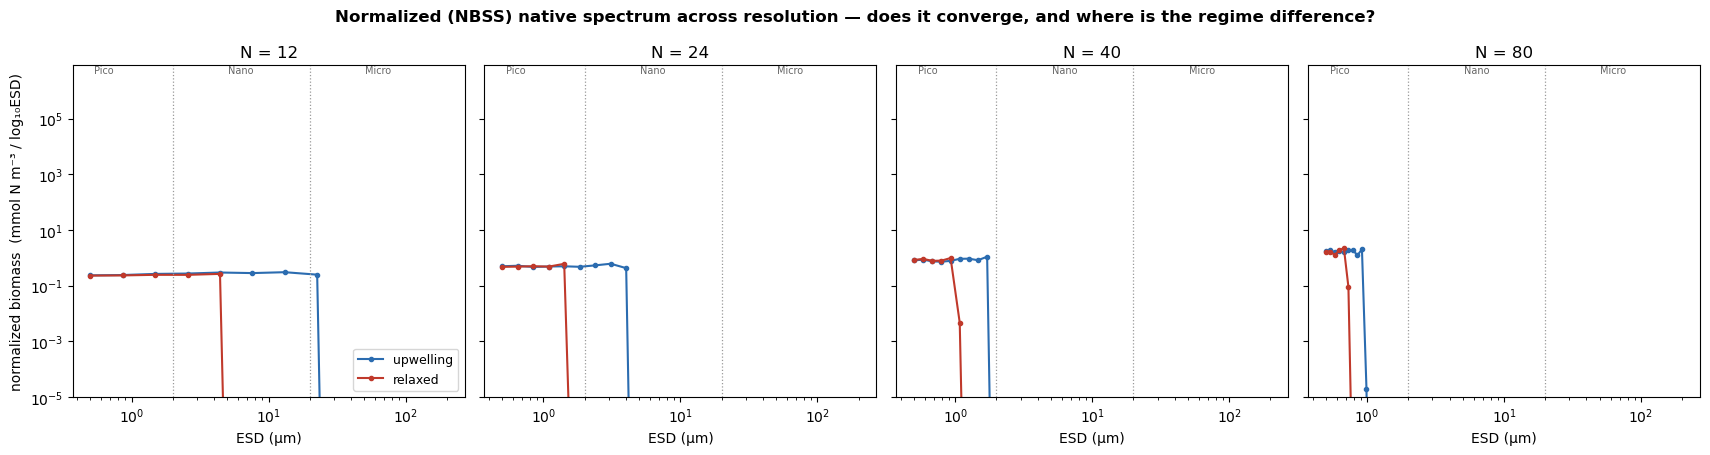

In [20]:
# ── Cell — NATIVE NORMALIZED spectrum (NBSS) across resolution, Sieburth bins marked ──
def _setup(N):
    esd = np.logspace(np.log10(0.5), np.log10(200.0), N); z = cbs.ZOO_PHYTO_RATIO*esd
    iv = {
        'Nutrient':{'value_label':'N','value_init':cbs.N_INIT},
        'Phytoplankton':{'biomass_label':'P','biomass_init':np.full(N,cbs.P_INIT),
                         'phyto_esd_index':esd.tolist(),'phyto_esd_label':'phyto_esd'},
        'Zooplankton':{'biomass_label':'Z','biomass_init':np.full(N,cbs.Z_INIT),
                       'zoo_esd_index':z.tolist(),'zoo_esd_label':'zoo_esd'},
        'Inflow':{'var':'N','FN':cbs.FN_DEFAULT,'de':cbs.DE_DEFAULT,'de_label':'de'},
        'Growth':{'resource':'N','consumer':'P','mu_max':mu_taniguchi(esd),'halfsat':ks_t(esd)},
        'Grazing':{'phyto':'P','zoo':'Z','nutrient':'N','Imax':imax_t(z),'KsZ':ksz_t(z),'gamma':cbs.GAMMA_VAL},
        'PhytoLoss':{'population':'P','nutrient':'N','rate':np.full(N,cbs.LAMBDA_VAL)},
        'ZooLoss':{'population':'Z','nutrient':'N','rate':np.full(N,cbs.DELTA_VAL)},
        'PhytoSinking':{'population':'P','w_sink':cbs.W_SINK,'de':'de'},
    }
    return xso.setup(solver='solve_ivp', model=cbs.model_baseline, time=cbs.ivp_time_array,
                     input_vars=iv, solver_kwargs=cbs.IVP_SOLVER_KWARGS), esd

N_list = [12, 24, 40, 80]; COL = {'upwelling':'#2b6cb0','relaxed':'#c0392b'}
spec = {N: {} for N in N_list}
for N in N_list:
    st, esd = _setup(N)
    dlog = (np.log10(esd[-1]) - np.log10(esd[0])) / (N - 1)    # per-class log10 ESD width
    for r in regimes:
        out  = pu.run_single_point(cbs.model_baseline, st, {}, fixed_overrides=targets[r]['forcing'])
        Pbar = out['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1)
        spec[N][r] = (esd, Pbar / dlog)                        # NBSS = biomass per unit log10 ESD

fig, ax = plt.subplots(1, len(N_list), figsize=(4.3*len(N_list), 4.6), sharey=True)
for a, N in zip(ax, N_list):
    for r in regimes:
        esd, nbss = spec[N][r]; a.plot(esd, nbss, 'o-', ms=3, color=COL[r], label=r)
    for b in (2.0, 20.0): a.axvline(b, ls=':', color='0.6', lw=0.9)
    a.set(xscale='log', yscale='log', title=f'N = {N}', xlabel='ESD (µm)', ylim=(1e-5, None))
    for xpos, lab in [(0.63,'Pico'), (6.3,'Nano'), (63,'Micro')]:
        a.text(xpos, a.get_ylim()[1], lab, ha='center', va='top', fontsize=7, color='0.4')
ax[0].set_ylabel('normalized biomass  (mmol N m⁻³ / log₁₀ESD)'); ax[0].legend(fontsize=9)
fig.suptitle('Normalized (NBSS) native spectrum across resolution — does it converge, and where is the regime difference?',
             weight='bold'); plt.tight_layout(); plt.show()

In [2]:
# ── Cell — variant definitions: 2×2 factorial (μ_max form × Pico floor) ──────
# One lever at a time. Variants differ ONLY in mu_max form and/or grid floor.
# k_s, I_max, K_sZ (Taniguchi'14 T1), Stock supply, phyto sinking, linear
# closure, r=10, Γ, Λ, Δ and N_CLASSES (=12) are identical across all four.
import xso

N = cbs.N_CLASSES                                    # 12, fixed for all variants
esd_05 = np.logspace(np.log10(0.5), np.log10(200.0), N)
esd_02 = np.logspace(np.log10(0.2), np.log10(200.0), N)
z05, z02 = cbs.ZOO_PHYTO_RATIO * esd_05, cbs.ZOO_PHYTO_RATIO * esd_02

mu_taniguchi = lambda s: 1.36 * s ** (-0.16)         # monotonic (Taniguchi'14 T1)
def mu_maranon(s):                                   # unimodal, peak 5.38 µm
    # Marañón et al. (2013), "Unimodal size scaling of phytoplankton growth and
    # the size dependence of nutrient uptake and use" — two-piece RMA, vol→ESD
    # (Size Spectral Setup Survey.md:79,85; mirrors cariaco_ssm_setup.py:38-45).
    return np.where(s <= 5.38, 0.33 * s ** 0.57, 1.83 * s ** (-0.45))
ks_t   = lambda s: 0.33  * s ** ( 0.48)              # unchanged (Taniguchi'14 T1)
imax_t = lambda z: 33.96 * z ** (-0.66)              # unchanged
ksz_t  = lambda z: 17.92 * z ** (-0.64)              # unchanged

# Variant A — baseline: Taniguchi μ, 0.5 µm floor  (full input_vars)
ivA = {
    'Nutrient':      {'value_label': 'N', 'value_init': cbs.N_INIT},
    'Phytoplankton': {'biomass_label': 'P', 'biomass_init': cbs.phyto_init,
                      'phyto_esd_index': esd_05.tolist(), 'phyto_esd_label': 'phyto_esd'},
    'Zooplankton':   {'biomass_label': 'Z', 'biomass_init': cbs.zoo_init,
                      'zoo_esd_index': z05.tolist(), 'zoo_esd_label': 'zoo_esd'},
    'Inflow':        {'var': 'N', 'FN': cbs.FN_DEFAULT, 'de': cbs.DE_DEFAULT, 'de_label': 'de'},
    'Growth':        {'resource': 'N', 'consumer': 'P',
                      'mu_max': mu_taniguchi(esd_05), 'halfsat': ks_t(esd_05)},
    'Grazing':       {'phyto': 'P', 'zoo': 'Z', 'nutrient': 'N',
                      'Imax': imax_t(z05), 'KsZ': ksz_t(z05), 'gamma': cbs.GAMMA_VAL},
    'PhytoLoss':     {'population': 'P', 'nutrient': 'N', 'rate': cbs.lambda_arr},
    'ZooLoss':       {'population': 'Z', 'nutrient': 'N', 'rate': cbs.delta_arr},
    'PhytoSinking':  {'population': 'P', 'w_sink': cbs.W_SINK, 'de': 'de'},
}
# Variant B — A + maranon growth (0.5 µm; only mu_max form flips)
ivB = {**ivA, 'Growth': {'resource': 'N', 'consumer': 'P',
                         'mu_max': mu_maranon(esd_05), 'halfsat': ks_t(esd_05)}}
# Variant C — A + extend pico 0.2 (Taniguchi μ; all grid-dependent arrays move)
ivC = {**ivA,
    'Phytoplankton': {'biomass_label': 'P', 'biomass_init': cbs.phyto_init,
                      'phyto_esd_index': esd_02.tolist(), 'phyto_esd_label': 'phyto_esd'},
    'Zooplankton':   {'biomass_label': 'Z', 'biomass_init': cbs.zoo_init,
                      'zoo_esd_index': z02.tolist(), 'zoo_esd_label': 'zoo_esd'},
    'Growth':        {'resource': 'N', 'consumer': 'P',
                      'mu_max': mu_taniguchi(esd_02), 'halfsat': ks_t(esd_02)},
    'Grazing':       {'phyto': 'P', 'zoo': 'Z', 'nutrient': 'N',
                      'Imax': imax_t(z02), 'KsZ': ksz_t(z02), 'gamma': cbs.GAMMA_VAL}}
# Variant D — C + maranon growth (0.2 µm; the interaction = proposed new baseline)
ivD = {**ivC, 'Growth': {'resource': 'N', 'consumer': 'P',
                         'mu_max': mu_maranon(esd_02), 'halfsat': ks_t(esd_02)}}

def _ivp(iv):
    return xso.setup(solver='solve_ivp', model=cbs.model_baseline,
                     time=cbs.ivp_time_array, input_vars=iv,
                     solver_kwargs=cbs.IVP_SOLVER_KWARGS)

VARIANTS = {
    'baseline (Taniguchi μ · 0.5µm)':  dict(setup=_ivp(ivA), esd=esd_05, zoo=z05),
    'maranon growth (· 0.5µm)':        dict(setup=_ivp(ivB), esd=esd_05, zoo=z05),
    'extend pico 0.2 (Taniguchi μ)':   dict(setup=_ivp(ivC), esd=esd_02, zoo=z02),  # expect unstable
    'maranon + extend pico 0.2':       dict(setup=_ivp(ivD), esd=esd_02, zoo=z02),
}
for name, v in VARIANTS.items():
    print(f"{name:34s}  μ(floor)={mu_maranon(v['esd'][:1])[0] if 'maranon' in name else mu_taniguchi(v['esd'][:1])[0]:.2f} d⁻¹"
          f"   floor={v['esd'][0]:.2g} µm")

baseline (Taniguchi μ · 0.5µm)      μ(floor)=1.52 d⁻¹   floor=0.5 µm
maranon growth (· 0.5µm)            μ(floor)=0.22 d⁻¹   floor=0.5 µm
extend pico 0.2 (Taniguchi μ)       μ(floor)=1.76 d⁻¹   floor=0.2 µm
maranon + extend pico 0.2           μ(floor)=0.13 d⁻¹   floor=0.2 µm


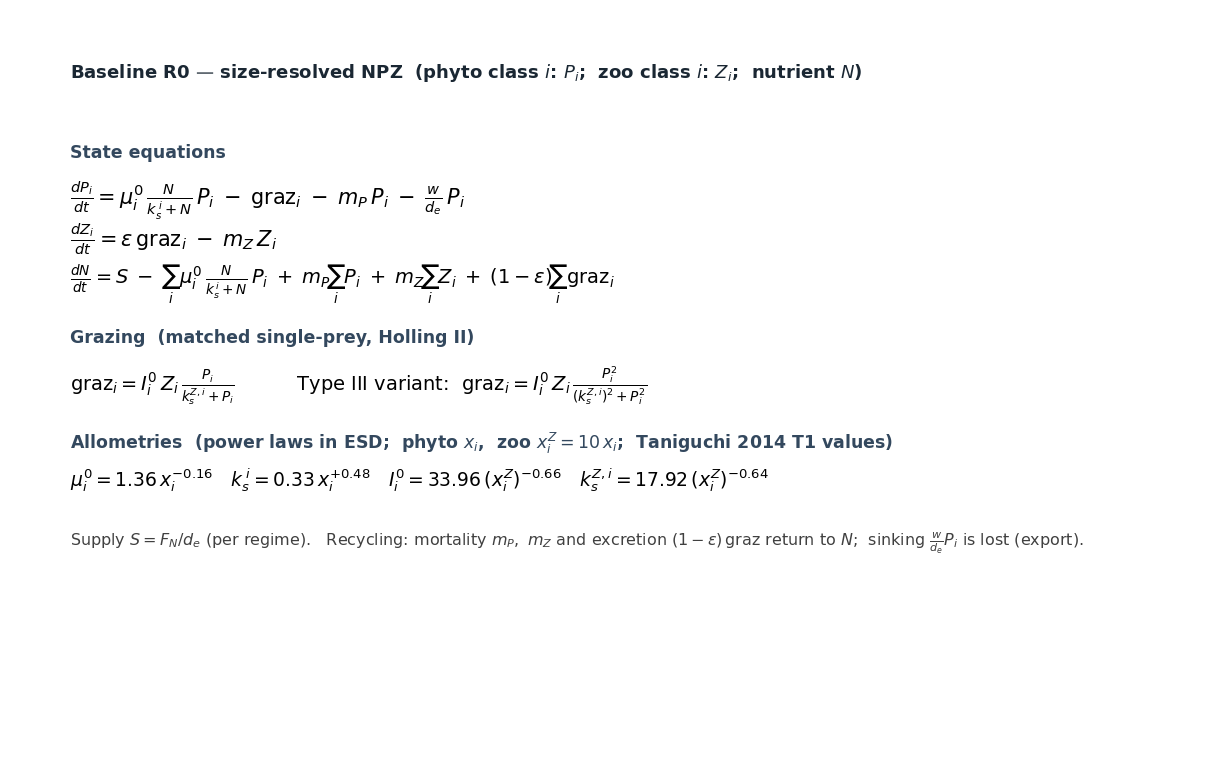

In [2]:
# ── Cell 2 — Fig 0: baseline model equations (Banas-2011 notation) ───────────
eq_blocks = [
    ("State equations",
     dict(size=12.5, weight='bold', color='#33485e', gap=0.4)),
    (r"$\frac{dP_i}{dt}=\mu^0_i\,\frac{N}{k_s^{\,i}+N}\,P_i\;-\;\mathrm{graz}_i"
     r"\;-\;m_P\,P_i\;-\;\frac{w}{d_e}\,P_i$", dict(size=15)),
    (r"$\frac{dZ_i}{dt}=\varepsilon\,\mathrm{graz}_i\;-\;m_Z\,Z_i$", dict(size=15)),
    (r"$\frac{dN}{dt}=S\;-\;\sum_i \mu^0_i\,\frac{N}{k_s^{\,i}+N}\,P_i"
     r"\;+\;m_P\!\sum_i P_i\;+\;m_Z\!\sum_i Z_i\;+\;(1-\varepsilon)\!\sum_i \mathrm{graz}_i$",
     dict(size=14)),
    ("Grazing  (matched single-prey, Holling II)",
     dict(size=12.5, weight='bold', color='#33485e', gap=0.7)),
    (r"$\mathrm{graz}_i=I^0_i\,Z_i\,\frac{P_i}{k_s^{Z,i}+P_i}$"
     r"          Type III variant:  "
     r"$\mathrm{graz}_i=I^0_i\,Z_i\,\frac{P_i^{2}}{(k_s^{Z,i})^{2}+P_i^{2}}$",
     dict(size=14)),
    (r"Allometries  (power laws in ESD;  phyto $x_i$,  zoo $x_i^{Z}=10\,x_i$;  "
     r"Taniguchi 2014 T1 values)",
     dict(size=12.5, weight='bold', color='#33485e', gap=0.7)),
    (r"$\mu^0_i=1.36\,x_i^{-0.16}\quad k_s^{\,i}=0.33\,x_i^{+0.48}\quad"
     r"I^0_i=33.96\,(x_i^{Z})^{-0.66}\quad k_s^{Z,i}=17.92\,(x_i^{Z})^{-0.64}$",
     dict(size=13.5)),
    (r"Supply $S=F_N/d_e$ (per regime).   Recycling: mortality $m_P,\ m_Z$ and "
     r"excretion $(1-\varepsilon)\,\mathrm{graz}$ return to $N$;  "
     r"sinking $\frac{w}{d_e}P_i$ is lost (export).",
     dict(size=11.5, color='0.25', gap=0.7)),
]

fig = pp.plot_equation_sheet(
    eq_blocks,
    title=r"Baseline R0 — size-resolved NPZ  "
          r"(phyto class $i$: $P_i$;  zoo class $i$: $Z_i$;  nutrient $N$)")
plt.show()

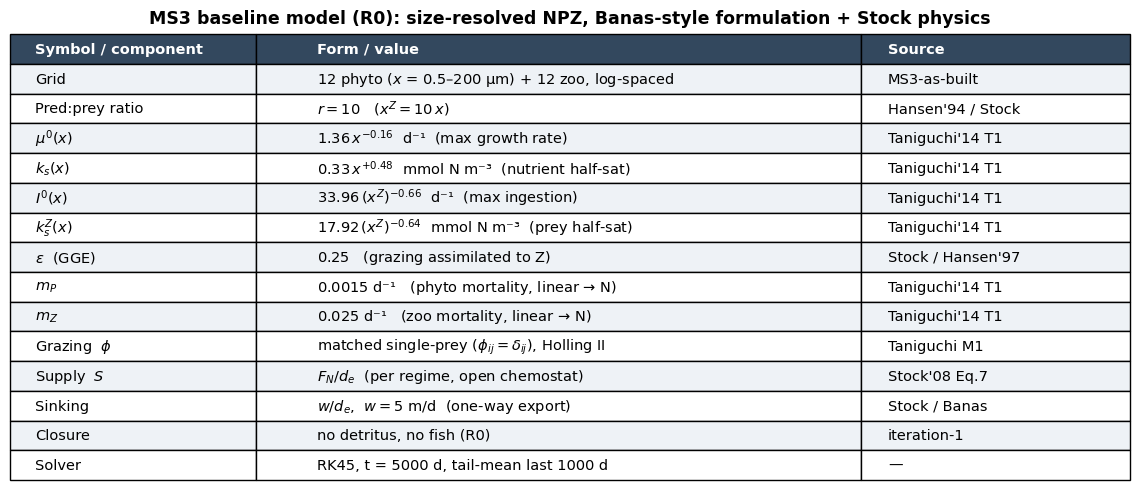

In [3]:
# ── Cell 3 — Fig 1: model structure & parameters ─────────────────────────────
lo, hi = cbs.phyto_esd[0], cbs.phyto_esd[-1]
rows = [
    ("Grid",             f"{cbs.N_CLASSES} phyto ($x$ = {lo:.2g}–{hi:.0f} µm) "
                         f"+ {cbs.N_CLASSES} zoo, log-spaced",                  "MS3-as-built"),
    ("Pred:prey ratio",  rf"$r = {cbs.ZOO_PHYTO_RATIO:.0f}$   "
                         rf"($x^{{Z}} = {cbs.ZOO_PHYTO_RATIO:.0f}\,x$)",        "Hansen'94 / Stock"),
    (r"$\mu^0(x)$",      r"$1.36\,x^{-0.16}$  d⁻¹  (max growth rate)",          "Taniguchi'14 T1"),
    (r"$k_s(x)$",        r"$0.33\,x^{+0.48}$  mmol N m⁻³  (nutrient half-sat)", "Taniguchi'14 T1"),
    (r"$I^0(x)$",        r"$33.96\,(x^{Z})^{-0.66}$  d⁻¹  (max ingestion)",     "Taniguchi'14 T1"),
    (r"$k_s^{Z}(x)$",    r"$17.92\,(x^{Z})^{-0.64}$  mmol N m⁻³  (prey half-sat)", "Taniguchi'14 T1"),
    (r"$\varepsilon$  (GGE)", f"${cbs.GAMMA_VAL}$   (grazing assimilated to Z)", "Stock / Hansen'97"),
    (r"$m_P$",           f"${cbs.LAMBDA_VAL}$ d⁻¹   (phyto mortality, linear → N)", "Taniguchi'14 T1"),
    (r"$m_Z$",           f"${cbs.DELTA_VAL}$ d⁻¹   (zoo mortality, linear → N)",    "Taniguchi'14 T1"),
    (r"Grazing  $\phi$", r"matched single-prey ($\phi_{ij}=\delta_{ij}$), Holling II", "Taniguchi M1"),
    (r"Supply  $S$",     r"$F_N/d_e$  (per regime, open chemostat)",            "Stock'08 Eq.7"),
    ("Sinking",          rf"$w/d_e$,  $w={cbs.W_SINK:.0f}$ m/d  (one-way export)", "Stock / Banas"),
    ("Closure",          "no detritus, no fish (R0)",                          "iteration-1"),
    ("Solver",           "RK45, t = 5000 d, tail-mean last 1000 d",            "—"),
]

fig = pp.plot_parameter_table(
    rows,
    title="MS3 baseline model (R0): size-resolved NPZ, "
          "Banas-style formulation + Stock physics")
plt.show()

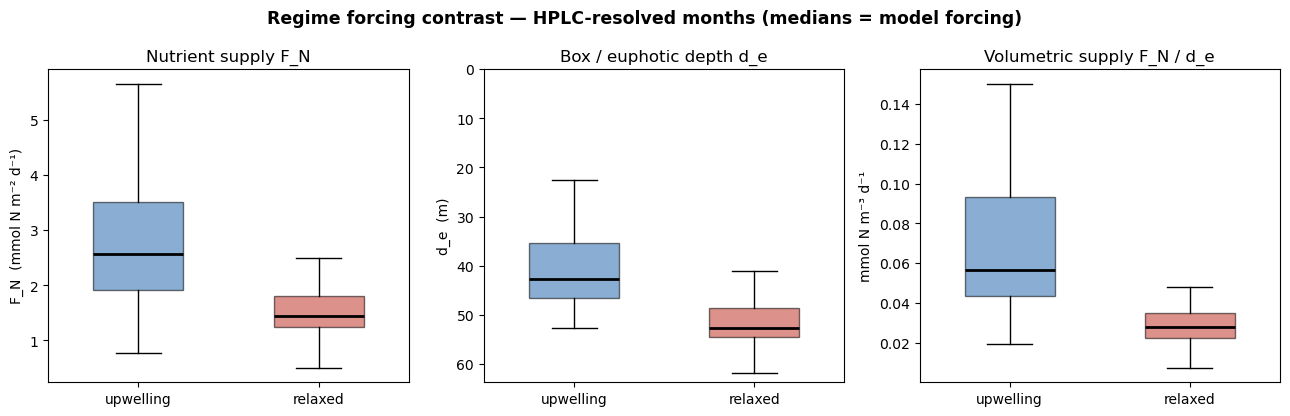

upwelling   n=31   F_N= 2.58   d_e= 42.8   F_N/d_e=0.0603
relaxed     n=58   F_N= 1.45   d_e= 52.7   F_N/d_e=0.0275


In [4]:
# ── Cell 4 — Fig 2: regime forcing (upwelling vs relaxed, HPLC months) ───────
regimes = ('upwelling', 'relaxed')

targets = {}
for r in regimes:
    obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
        regime=r, months='hplc', agg='median')
    targets[r] = dict(obs_vec=obs_vec, monthly_df=monthly_df, forcing=forcing)

fig = pp.plot_regime_forcing({r: targets[r]['monthly_df'] for r in regimes},
                             regimes=regimes)
plt.show()

for r in regimes:
    f = targets[r]['forcing']
    print(f"{r:10s}  n={len(targets[r]['monthly_df']):2d}   "
          f"F_N={f['Inflow__FN']:5.2f}   d_e={f['Inflow__de']:5.1f}   "
          f"F_N/d_e={f['Inflow__FN']/f['Inflow__de']:.4f}")

In [5]:
# ── Cell — run all variants × regimes (crash-caught) → processed structures ──
TAIL = 1000
obs_by_regime = {r: pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)
                 for r in regimes}

runs = {}                       # runs[name][regime] = processed dict or None
for name, v in VARIANTS.items():
    runs[name] = {}
    for r in regimes:
        try:
            out  = pu.run_single_point(cbs.model_baseline, v['setup'],
                                       scan_params={}, fixed_overrides=targets[r]['forcing'])
            proc = pu.process_regime_run(out, v['esd'], v['zoo'], bin_defs, tail_len=TAIL)
            ok   = (np.isfinite(proc['sumP_tail']).all()
                    and np.isfinite(proc['mcs_tail']).all())
            runs[name][r], tag = (proc, 'ok') if ok else (None, 'NON-FINITE')
        except Exception as e:
            runs[name][r], tag = None, f'CRASHED ({type(e).__name__})'
        p = runs[name][r]
        msg = (f"CV={p['cv']:5.2f}  mcs={np.nanmedian(p['mcs_tail']):4.1f}µm"
               if p is not None else "")
        print(f"{name:32s} {r:10s}  {msg:28s}[{tag}]")

baseline (Taniguchi μ · 0.5µm)   upwelling   CV= 0.29  mcs= 3.5µm        [ok]
baseline (Taniguchi μ · 0.5µm)   relaxed     CV= 0.08  mcs= 1.6µm        [ok]
maranon growth (· 0.5µm)         upwelling   CV= 0.21  mcs= 3.9µm        [ok]
maranon growth (· 0.5µm)         relaxed     CV= 0.04  mcs= 2.9µm        [ok]
extend pico 0.2 (Taniguchi μ)    upwelling   CV= 0.19  mcs= 2.3µm        [ok]
extend pico 0.2 (Taniguchi μ)    relaxed     CV= 0.06  mcs= 0.9µm        [ok]
maranon + extend pico 0.2        upwelling   CV= 0.41  mcs= 4.1µm        [ok]
maranon + extend pico 0.2        relaxed     CV= 0.06  mcs= 3.3µm        [ok]


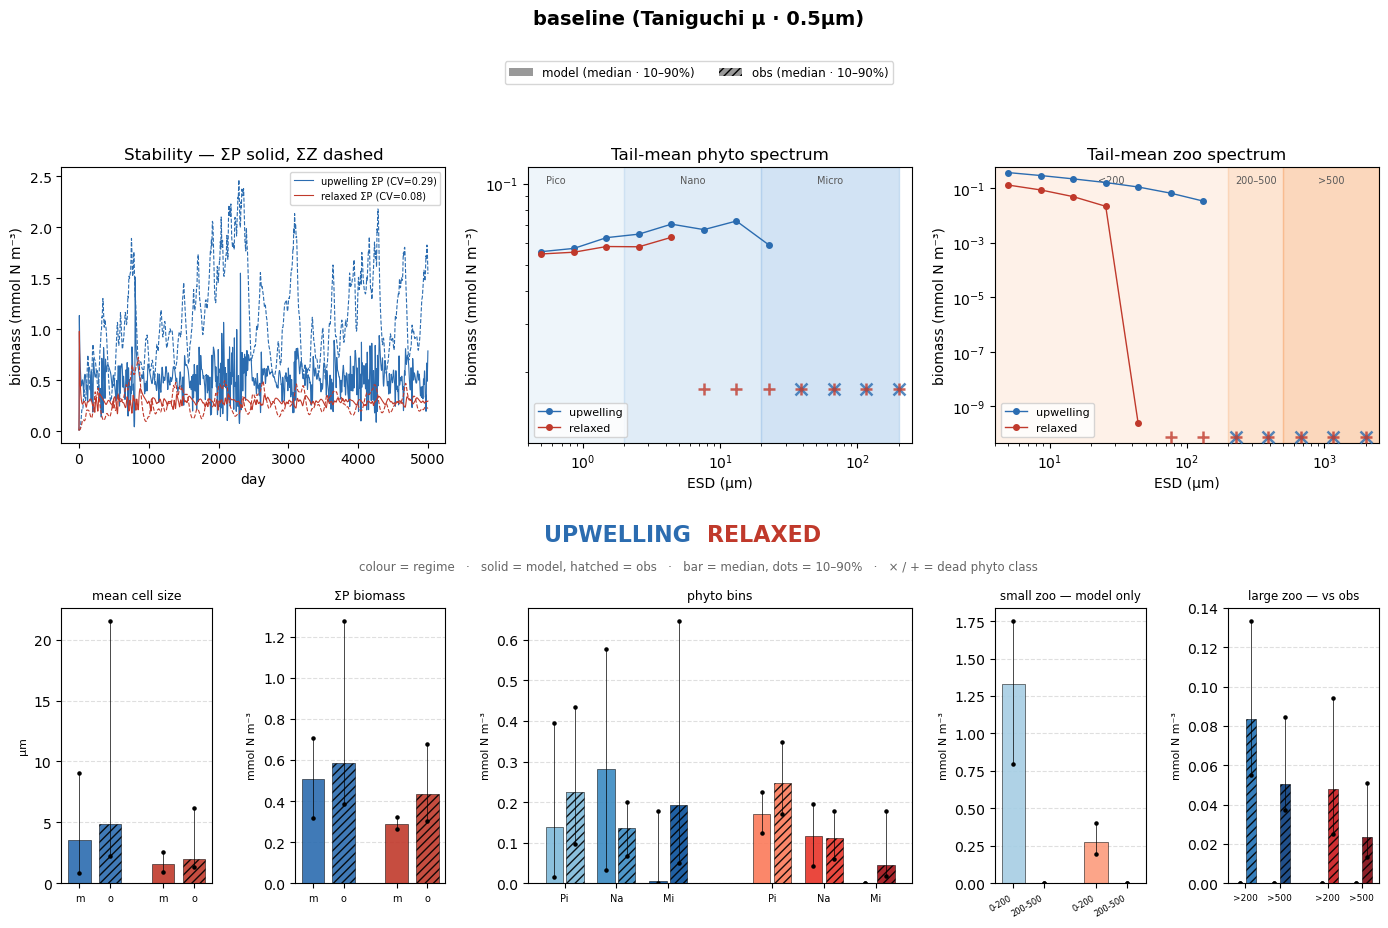

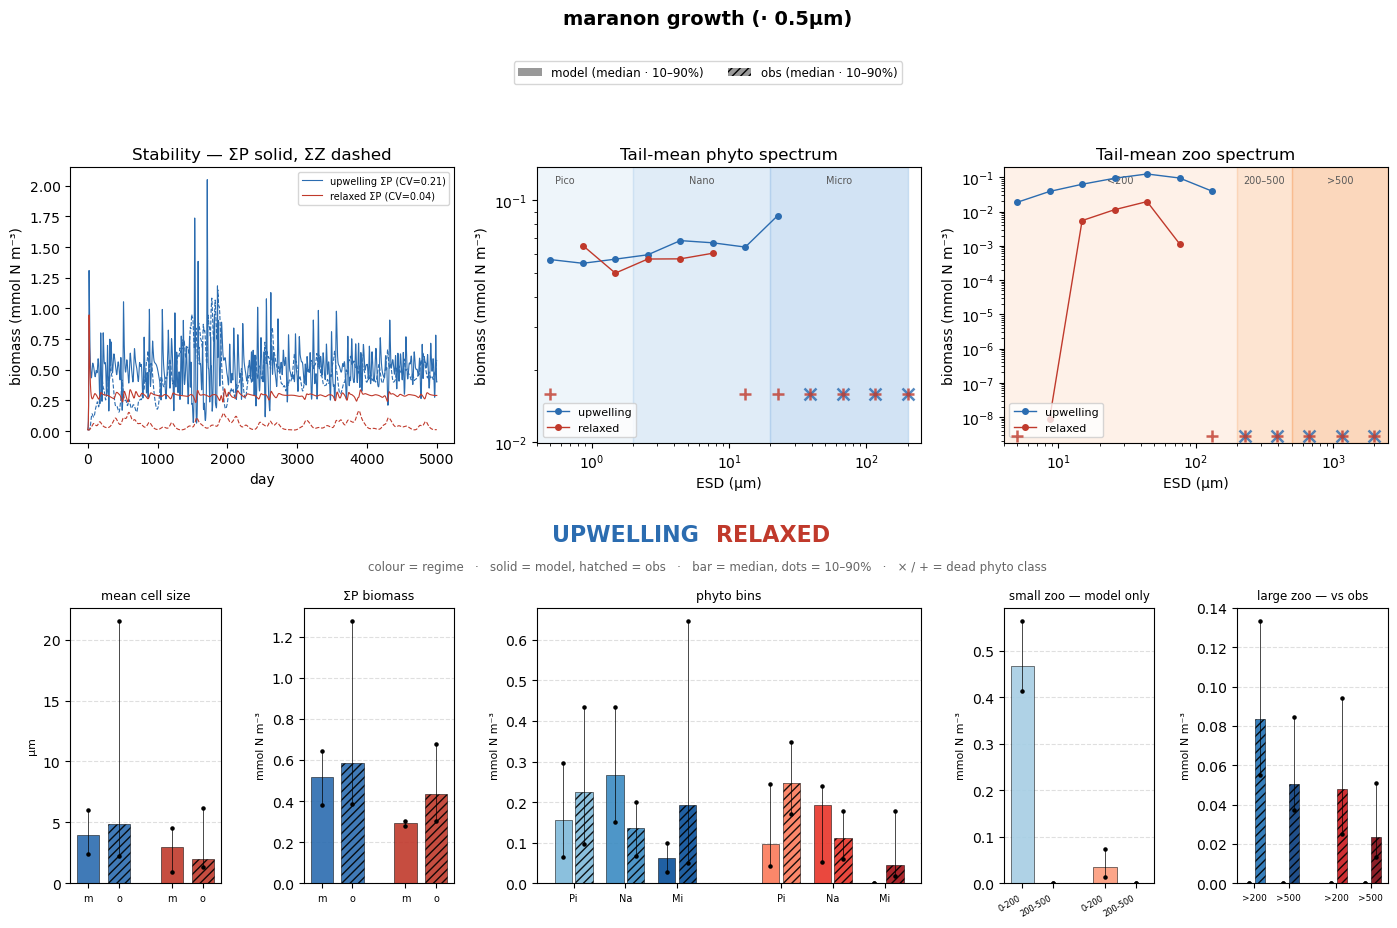

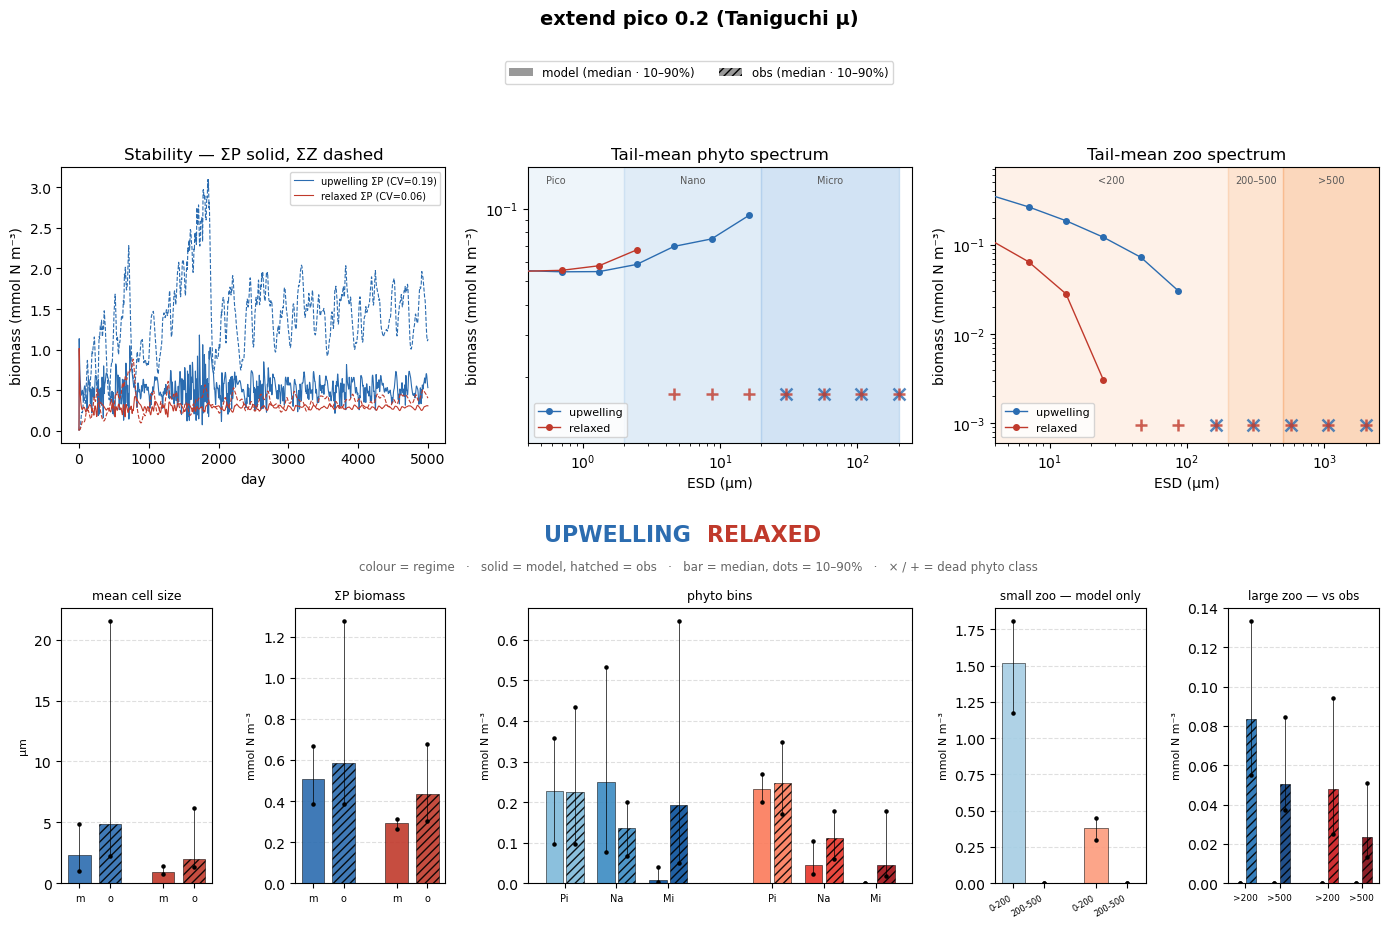

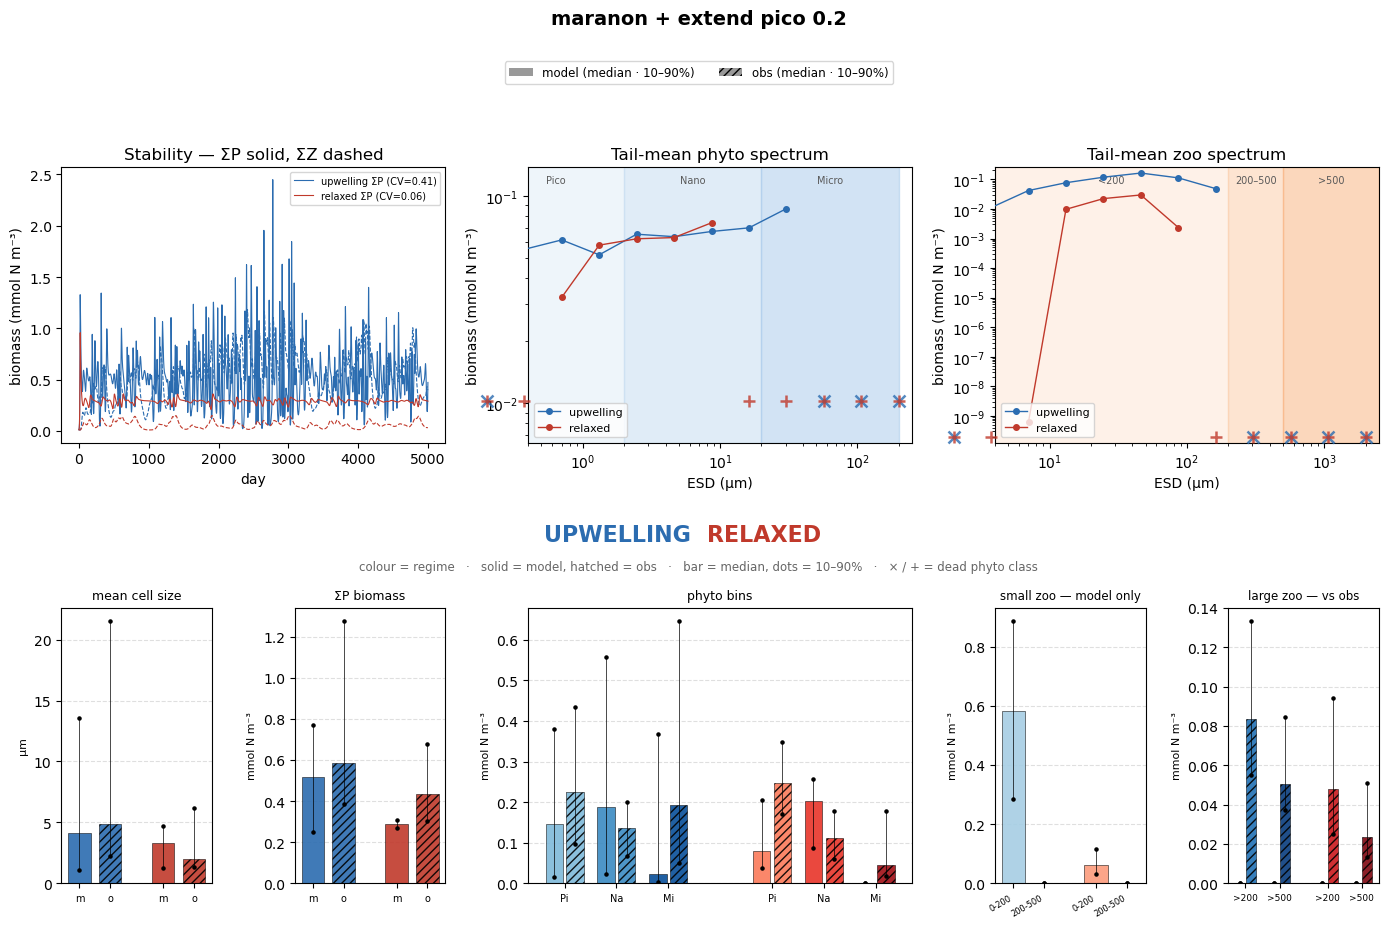

In [6]:
# ── Cell — existing regime diagnostic per variant (only if both regimes ran) ──
for name, v in VARIANTS.items():
    mbr = {r: runs[name][r] for r in regimes if runs[name][r] is not None}
    if len(mbr) < len(regimes):
        print(f"– '{name}': {len(mbr)}/{len(regimes)} regimes ran — "
              f"no full diagnostic (the instability is the result here)")
        continue
    fig = pp.plot_regime_diagnostic(mbr, {r: obs_by_regime[r] for r in regimes},
                                    v['esd'], v['zoo'], regimes=regimes, title=name)
    plt.show()

In [7]:
# ── Cell — small-class grazing diagnostic (the zoo-overreach check) ──────────
# G_i = I_max_i · Z_i · P_i/(P_i + K_sZ_i), matched index. Watches whether low
# Marañón small-phyto biomass (P0) curtails the small-zoo loop that the extended
# zoo allometry (Imax0 rises as the floor drops) would otherwise drive.
hdr = f"{'variant':32s} {'regime':10s} {'zoo0µm':>7s} {'Imax0':>6s} {'P0':>8s} {'Z0':>8s} {'G0':>8s} {'argmaxG':>7s}"
print(hdr)
for name, v in VARIANTS.items():
    Imax, KsZ = imax_t(v['zoo']), ksz_t(v['zoo'])
    for r in regimes:
        p = runs[name][r]
        if p is None:
            print(f"{name:32s} {r:10s}   [no run]");  continue
        P, Z = p['Pspec'], p['Zspec']
        G = Imax * Z * P / (P + KsZ)
        print(f"{name:32s} {r:10s} {v['zoo'][0]:7.2g} {Imax[0]:6.1f} "
              f"{P[0]:8.2g} {Z[0]:8.2g} {G[0]:8.2g} {int(np.argmax(G)):7d}")

variant                          regime      zoo0µm  Imax0       P0       Z0       G0 argmaxG
baseline (Taniguchi μ · 0.5µm)   upwelling        5   11.7    0.056     0.37    0.038       0
baseline (Taniguchi μ · 0.5µm)   relaxed          5   11.7    0.055     0.13    0.013       0
maranon growth (· 0.5µm)         upwelling        5   11.7    0.057    0.019   0.0019       4
maranon growth (· 0.5µm)         relaxed          5   11.7  4.5e-25  1.6e-48  1.3e-72       4
extend pico 0.2 (Taniguchi μ)    upwelling        2   21.5    0.054     0.47    0.047       0
extend pico 0.2 (Taniguchi μ)    relaxed          2   21.5    0.054     0.18    0.018       0
maranon + extend pico 0.2        upwelling        2   21.5  3.1e-28  1.5e-48    9e-76       5
maranon + extend pico 0.2        relaxed          2   21.5  5.6e-57  1.5e-48 1.6e-104       5


In [12]:
# ── Cell — build_variants (now also returns a 'stab' setup per variant) ──────
def build_variants(N):
    e05 = np.logspace(np.log10(0.5), np.log10(200.0), N)
    e02 = np.logspace(np.log10(0.2), np.log10(200.0), N)
    pinit, zinit = np.full(N, cbs.P_INIT), np.full(N, cbs.Z_INIT)
    lam, dlt = np.full(N, cbs.LAMBDA_VAL), np.full(N, cbs.DELTA_VAL)
    def iv(esd, mu_fn):
        z = cbs.ZOO_PHYTO_RATIO * esd
        return {
            'Nutrient':      {'value_label':'N','value_init':cbs.N_INIT},
            'Phytoplankton': {'biomass_label':'P','biomass_init':pinit,
                              'phyto_esd_index':esd.tolist(),'phyto_esd_label':'phyto_esd'},
            'Zooplankton':   {'biomass_label':'Z','biomass_init':zinit,
                              'zoo_esd_index':z.tolist(),'zoo_esd_label':'zoo_esd'},
            'Inflow':        {'var':'N','FN':cbs.FN_DEFAULT,'de':cbs.DE_DEFAULT,'de_label':'de'},
            'Growth':        {'resource':'N','consumer':'P','mu_max':mu_fn(esd),'halfsat':ks_t(esd)},
            'Grazing':       {'phyto':'P','zoo':'Z','nutrient':'N',
                              'Imax':imax_t(z),'KsZ':ksz_t(z),'gamma':cbs.GAMMA_VAL},
            'PhytoLoss':     {'population':'P','nutrient':'N','rate':lam},
            'ZooLoss':       {'population':'Z','nutrient':'N','rate':dlt},
            'PhytoSinking':  {'population':'P','w_sink':cbs.W_SINK,'de':'de'},
        }
    specs = {'baseline (Taniguchi μ · 0.5µm)': (e05, mu_taniguchi),
             'maranon growth (· 0.5µm)':       (e05, mu_maranon),
             'extend pico 0.2 (Taniguchi μ)':  (e02, mu_taniguchi),
             'maranon + extend pico 0.2':      (e02, mu_maranon)}
    out = {}
    for name, (esd, mu_fn) in specs.items():
        v = iv(esd, mu_fn)
        out[name] = dict(
            setup=xso.setup(solver='solve_ivp', model=cbs.model_baseline,
                            time=cbs.ivp_time_array, input_vars=v,
                            solver_kwargs=cbs.IVP_SOLVER_KWARGS),
            stab =xso.setup(solver='stability', model=cbs.model_baseline,
                            time=cbs.STAB_TIME, input_vars=v),
            esd=esd, zoo=cbs.ZOO_PHYTO_RATIO*esd)
    return out

In [9]:
# ── Cell — confirm the N=40 attractor: monoculture vs coexisting spectrum ─────
TOL = 1e-3                                   # "alive" = within TOL of the max class
print(f"{'variant':32s} {'regime':10s} {'n_alive':>7s} {'peakESD':>7s} {'domFrac':>7s} {'ΣP':>6s}")
for name, v in build_variants(40).items():
    for r in regimes:
        out = pu.run_single_point(cbs.model_baseline, v['setup'], {},
                                  fixed_overrides=targets[r]['forcing'])
        P = out['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1)
        alive = P > TOL * P.max()
        print(f"{name:32s} {r:10s} {alive.sum():7d} "
              f"{v['esd'][P.argmax()]:7.2g} {P.max()/P.sum():7.2f} {P.sum():6.3f}")

variant                          regime     n_alive peakESD domFrac     ΣP
baseline (Taniguchi μ · 0.5µm)   upwelling        9     1.7    0.14  0.517
baseline (Taniguchi μ · 0.5µm)   relaxed          6    0.92    0.23  0.290
maranon growth (· 0.5µm)         upwelling        9     6.8    0.18  0.516
maranon growth (· 0.5µm)         relaxed          5     5.8    0.23  0.290
extend pico 0.2 (Taniguchi μ)    upwelling        9    0.58    0.12  0.513
extend pico 0.2 (Taniguchi μ)    relaxed          6    0.34    0.21  0.288
maranon + extend pico 0.2        upwelling        9     6.9    0.17  0.516
maranon + extend pico 0.2        relaxed          5     3.4    0.25  0.290


variant                          regime      mcs_bin  mcs_native
baseline (Taniguchi μ · 0.5µm)   upwelling       0.6        0.95
baseline (Taniguchi μ · 0.5µm)   relaxed         0.6        0.68
maranon growth (· 0.5µm)         upwelling       6.2        3.99
maranon growth (· 0.5µm)         relaxed         6.3        4.36
extend pico 0.2 (Taniguchi μ)    upwelling       0.6        0.41
extend pico 0.2 (Taniguchi μ)    relaxed         0.6        0.29
maranon + extend pico 0.2        upwelling       6.0        3.91
maranon + extend pico 0.2        relaxed         6.3        4.05


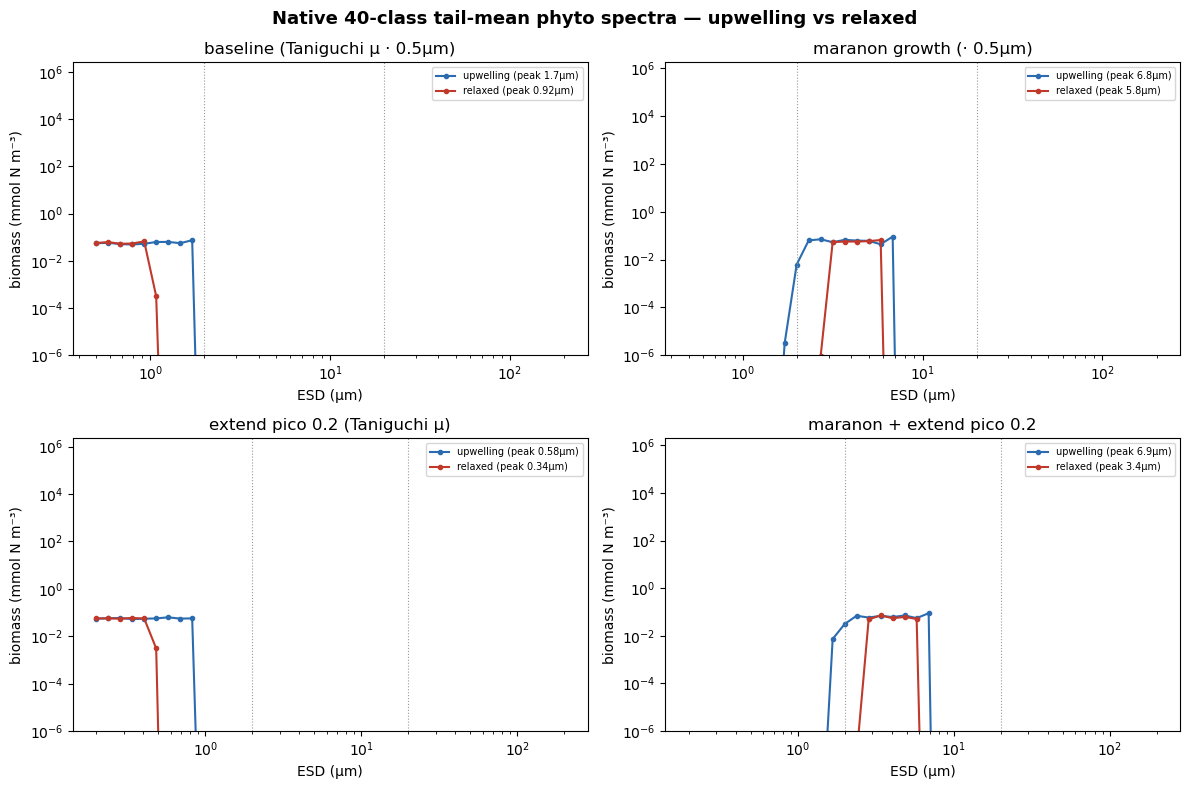

In [10]:
# ── Cell — native 40-class spectra (up vs rel) + binned-vs-native mcs gap ─────
COL = {'upwelling': '#2b6cb0', 'relaxed': '#c0392b'}
v40 = build_variants(40)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
print(f"{'variant':32s} {'regime':10s} {'mcs_bin':>8s} {'mcs_native':>11s}")
for ax, (name, v) in zip(axes.flat, v40.items()):
    for r in regimes:
        out  = pu.run_single_point(cbs.model_baseline, v['setup'], {},
                                   fixed_overrides=targets[r]['forcing'])
        P    = out['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1)
        frac = P / P.sum()
        mcs_native = 10 ** (frac @ np.log10(v['esd']))
        proc = pu.process_regime_run(out, v['esd'], v['zoo'], bin_defs, tail_len=TAIL)
        ax.plot(v['esd'], P, 'o-', ms=3, color=COL[r],
                label=f"{r} (peak {v['esd'][P.argmax()]:.2g}µm)")
        print(f"{name:32s} {r:10s} {float(np.nanmedian(proc['mcs_tail'])):8.1f} {mcs_native:11.2f}")
    for b in (2.0, 20.0):                         # Sieburth Pico|Nano|Micro bounds
        ax.axvline(b, ls=':', color='0.6', lw=0.8)
    ax.set(xscale='log', yscale='log', title=name, xlabel='ESD (µm)',
           ylabel='biomass (mmol N m⁻³)', ylim=(1e-6, None))
    ax.legend(fontsize=7)
fig.suptitle('Native 40-class tail-mean phyto spectra — upwelling vs relaxed',
             fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

In [11]:
# ── Cell — resolution-invariance of total biomass + box mass balance ─────────
# Only sinks/sources on the box N inventory (N+ΣP+ΣZ) are supply F_N/d_e and
# export (w/d_e)·ΣP — all biology recycles. Tail-mean ⇒ ΣP ≈ F_N/w_sink at any
# class count. Residual = 1 − w·ΣP/F_N should sit near 0.
W = cbs.W_SINK
print(f"{'variant':32s} {'regime':10s} {'N':>3s} {'ΣP':>6s} {'F_N/w':>6s} {'resid':>7s}")
for Nc in (12, 40):
    for name, v in build_variants(Nc).items():
        for r in regimes:
            fN  = targets[r]['forcing']['Inflow__FN']
            out = pu.run_single_point(cbs.model_baseline, v['setup'], {},
                                      fixed_overrides=targets[r]['forcing'])
            sumP = out['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1).sum()
            print(f"{name:32s} {r:10s} {Nc:3d} {sumP:6.3f} {fN/W:6.3f} {1 - W*sumP/fN:+7.3f}")

variant                          regime       N     ΣP  F_N/w   resid
baseline (Taniguchi μ · 0.5µm)   upwelling   12  0.511  0.516  +0.009
baseline (Taniguchi μ · 0.5µm)   relaxed     12  0.290  0.290  -0.001
maranon growth (· 0.5µm)         upwelling   12  0.515  0.516  +0.002
maranon growth (· 0.5µm)         relaxed     12  0.290  0.290  -0.002
extend pico 0.2 (Taniguchi μ)    upwelling   12  0.516  0.516  -0.000
extend pico 0.2 (Taniguchi μ)    relaxed     12  0.289  0.290  +0.002
maranon + extend pico 0.2        upwelling   12  0.522  0.516  -0.012
maranon + extend pico 0.2        relaxed     12  0.290  0.290  +0.001
baseline (Taniguchi μ · 0.5µm)   upwelling   40  0.517  0.516  -0.002
baseline (Taniguchi μ · 0.5µm)   relaxed     40  0.290  0.290  +0.000
maranon growth (· 0.5µm)         upwelling   40  0.516  0.516  +0.000
maranon growth (· 0.5µm)         relaxed     40  0.290  0.290  -0.000
extend pico 0.2 (Taniguchi μ)    upwelling   40  0.513  0.516  +0.005
extend pico 0.2 (Tan

In [13]:
# ── Cell — fixed point + eigenvalues per variant × regime × {12, 40} ─────────
# fsolve seeded from the IVP tail-mean (the basin the orbit circles), then
# Jacobian eigenvalues. mcs_fix vs mcs_orb = focus-vs-orbit agreement: equal ⇒
# genuinely settled on the fixed point; divergent ⇒ orbiting an unstable focus.
from xso.parscans import StabilityAnalysisHook

def tail_mean_seed(out, w=TAIL):
    return {'Nutrient__value_init': float(out['Nutrient__value'].values[-w:].mean()),
            'Phytoplankton__biomass_init': np.maximum(
                out['Phytoplankton__biomass'].values[:, -w:].mean(axis=1), 1e-9),
            'Zooplankton__biomass_init': np.maximum(
                out['Zooplankton__biomass'].values[:, -w:].mean(axis=1), 1e-9)}

def run_stability(stab_setup, forcing, seed):
    hook = StabilityAnalysisHook()
    with cbs.model_baseline:
        out = (stab_setup.xsimlab.update_vars(input_vars={**forcing, **seed})
               .xsimlab.run(hooks=[hook]))
    return out, hook.get_results()

def _mcs(P, esd):
    P = np.asarray(P, float)
    return 10 ** ((P / P.sum()) @ np.log10(esd))

print(f"{'variant':32s} {'reg':9s} {'N':>3s} {'stability':>10s} {'maxReλ':>8s} "
      f"{'nPos':>4s} {'nCx':>4s} {'mcs_fix':>7s} {'mcs_orb':>7s}")
for Nc in (12, 40):
    for name, v in build_variants(Nc).items():
        for r in regimes:
            f   = targets[r]['forcing']
            ivp = pu.run_single_point(cbs.model_baseline, v['setup'], {}, fixed_overrides=f)
            out_s, s = run_stability(v['stab'], f, tail_mean_seed(ivp))
            P_fix = out_s['Phytoplankton__biomass'].isel(time=-1).values
            P_orb = ivp['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1)
            print(f"{name:32s} {r:9s} {Nc:3d} {s['stability']:>10s} "
                  f"{s['max_eigenvalue_real']:+8.4f} {s['n_positive_eigenvalues']:4d} "
                  f"{s['n_complex_pairs']:4d} {_mcs(P_fix, v['esd']):7.2f} {_mcs(P_orb, v['esd']):7.2f}")

variant                          reg         N  stability   maxReλ nPos  nCx mcs_fix mcs_orb
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 1.3492e-02
baseline (Taniguchi μ · 0.5µm)   upwelling  12   unstable  +0.0135   13    8    4.20    3.58
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 2.3405e-03
baseline (Taniguchi μ · 0.5µm)   relaxed    12   unstable  +0.0023    7    4    1.55    1.54
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 1.3492e-02
maranon growth (· 0.5µm)         upwelling  12   unstable  +0.0135   13    8    4.20    3.92
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 5.2137e-04
maranon growth (· 0.

In [14]:
# ── Cell — resolution-convergence sweep: do focus + orbit asymptote? ─────────
N_LIST = [12, 24, 40, 80]                      # add 120/160 for a finer tail
V = {Nc: build_variants(Nc) for Nc in N_LIST}  # build each resolution once
print(f"{'variant':32s} {'reg':9s} {'N':>3s} {'mcs_fix':>7s} {'mcs_orb':>7s} "
      f"{'CV':>5s} {'alive':>5s} {'maxReλ':>8s}")
for name0 in V[N_LIST[0]]:
    for r in regimes:
        for Nc in N_LIST:
            v = V[Nc][name0]; f = targets[r]['forcing']
            ivp = pu.run_single_point(cbs.model_baseline, v['setup'], {}, fixed_overrides=f)
            P     = ivp['Phytoplankton__biomass'].values
            P_orb = P[:, -TAIL:].mean(axis=1)
            sP    = P.sum(axis=0)[-TAIL:]
            out_s, s = run_stability(v['stab'], f, tail_mean_seed(ivp))
            P_fix = out_s['Phytoplankton__biomass'].isel(time=-1).values
            print(f"{name0:32s} {r:9s} {Nc:3d} {_mcs(P_fix,v['esd']):7.2f} "
                  f"{_mcs(P_orb,v['esd']):7.2f} {sP.std()/sP.mean():5.2f} "
                  f"{int((P_orb>1e-3*P_orb.max()).sum()):5d} {s['max_eigenvalue_real']:+8.4f}")

variant                          reg         N mcs_fix mcs_orb    CV alive   maxReλ
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 1.3492e-02
baseline (Taniguchi μ · 0.5µm)   upwelling  12    4.20    3.58  0.29     8  +0.0135
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 2.1907e-03
baseline (Taniguchi μ · 0.5µm)   upwelling  24    1.45    1.43  0.08     9  +0.0022
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 5.3962e-03
baseline (Taniguchi μ · 0.5µm)   upwelling  40    0.94    0.95  0.06     9  +0.0054
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 7.5305e-03
baseline (Taniguchi μ · 0.5µm)   upwelling  80    0.68  

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1285 on P[1] = -0.00559. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_97790/1918857448.py:36: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian(proc['mcs_tail']), proc['cv']
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1813 on P[0] = -0.00222. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_97790/1918857448

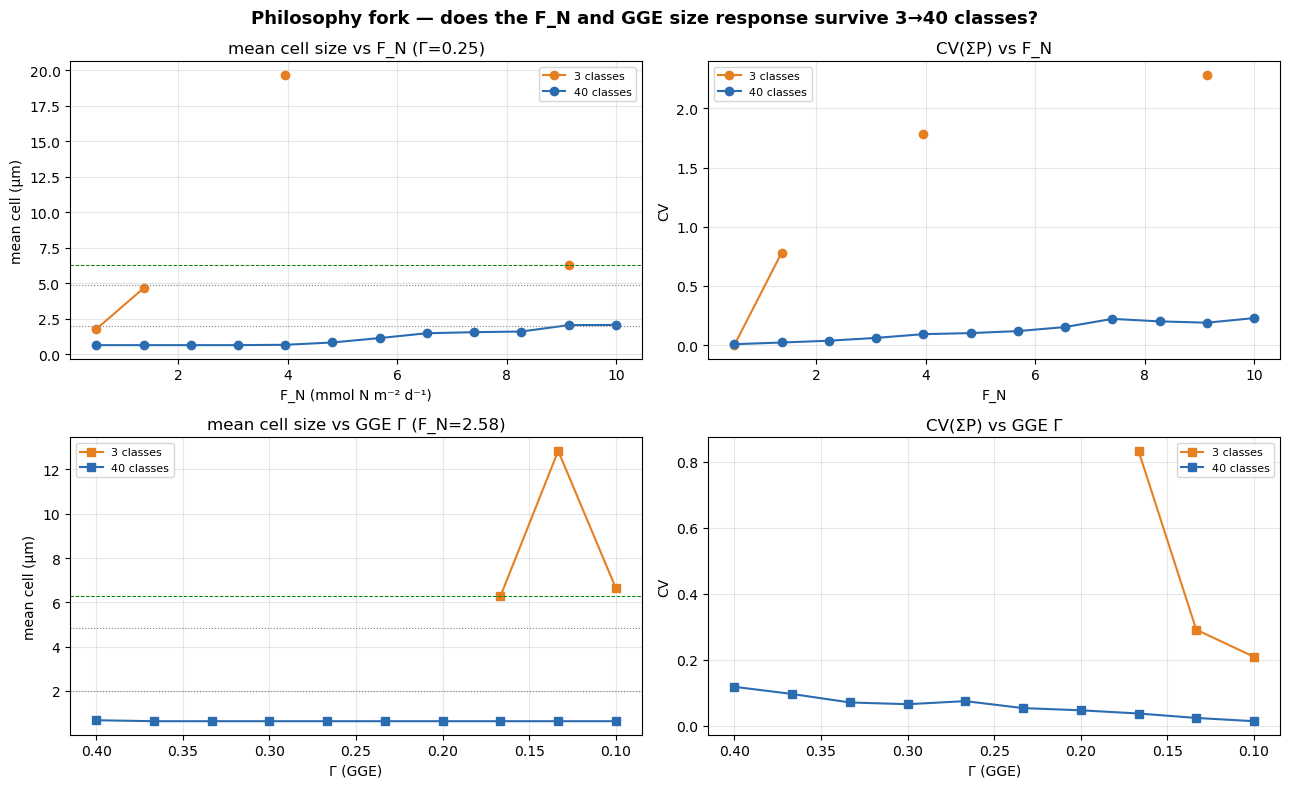

In [15]:
# ── Cell — philosophy fork: F_N and GGE response at 3 vs 40 classes ──────────
def make_ivp_setup(esd, mu_fn=mu_taniguchi):
    esd = np.asarray(esd, float); N = len(esd); z = cbs.ZOO_PHYTO_RATIO * esd
    iv = {
        'Nutrient':      {'value_label':'N','value_init':cbs.N_INIT},
        'Phytoplankton': {'biomass_label':'P','biomass_init':np.full(N, cbs.P_INIT),
                          'phyto_esd_index':esd.tolist(),'phyto_esd_label':'phyto_esd'},
        'Zooplankton':   {'biomass_label':'Z','biomass_init':np.full(N, cbs.Z_INIT),
                          'zoo_esd_index':z.tolist(),'zoo_esd_label':'zoo_esd'},
        'Inflow':        {'var':'N','FN':cbs.FN_DEFAULT,'de':cbs.DE_DEFAULT,'de_label':'de'},
        'Growth':        {'resource':'N','consumer':'P','mu_max':mu_fn(esd),'halfsat':ks_t(esd)},
        'Grazing':       {'phyto':'P','zoo':'Z','nutrient':'N','Imax':imax_t(z),'KsZ':ksz_t(z),'gamma':cbs.GAMMA_VAL},
        'PhytoLoss':     {'population':'P','nutrient':'N','rate':np.full(N, cbs.LAMBDA_VAL)},
        'ZooLoss':       {'population':'Z','nutrient':'N','rate':np.full(N, cbs.DELTA_VAL)},
        'PhytoSinking':  {'population':'P','w_sink':cbs.W_SINK,'de':'de'},
    }
    st = xso.setup(solver='solve_ivp', model=cbs.model_baseline, time=cbs.ivp_time_array,
                   input_vars=iv, solver_kwargs=cbs.IVP_SOLVER_KWARGS)
    return dict(setup=st, esd=esd, zoo=z)

esd3  = np.array([0.63, 6.3, 63.0])                       # Sieburth geomeans (functional groups)
esd40 = np.logspace(np.log10(0.2), np.log10(200.0), 40)  # continuum
SET = {3: make_ivp_setup(esd3), 40: make_ivp_setup(esd40)}

DE      = cbs.DE_DEFAULT                                  # fixed box depth for both sweeps
fn_vals = np.linspace(0.5, 10.0, 12)
g_vals  = np.linspace(0.40, 0.10, 10)                     # high → low GGE
FN_GGE  = 2.58                                            # ~upwelling F_N for the GGE sweep
obs_mcs = {r: np.nanmedian(pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)['mcs'])
           for r in regimes}

def metrics(res, ovr):
    s = SET[res]
    out  = pu.run_single_point(cbs.model_baseline, s['setup'], {}, fixed_overrides=ovr)
    proc = pu.process_regime_run(out, s['esd'], s['zoo'], bin_defs, tail_len=TAIL)
    return np.nanmedian(proc['mcs_tail']), proc['cv']

res_list = [3, 40]
fnR = {res: np.array([metrics(res, {'Inflow__FN':fn,'Inflow__de':DE,'Grazing__gamma':0.25}) for fn in fn_vals]) for res in res_list}
ggR = {res: np.array([metrics(res, {'Inflow__FN':FN_GGE,'Inflow__de':DE,'Grazing__gamma':g}) for g in g_vals]) for res in res_list}

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
col = {3: '#e67e22', 40: '#2b6cb0'}
for res in res_list:
    ax[0,0].plot(fn_vals, fnR[res][:,0], 'o-', color=col[res], label=f'{res} classes')
    ax[0,1].plot(fn_vals, fnR[res][:,1], 'o-', color=col[res], label=f'{res} classes')
    ax[1,0].plot(g_vals,  ggR[res][:,0], 's-', color=col[res], label=f'{res} classes')
    ax[1,1].plot(g_vals,  ggR[res][:,1], 's-', color=col[res], label=f'{res} classes')
for a in (ax[0,0], ax[1,0]):
    for r in regimes: a.axhline(obs_mcs[r], ls=':', color='0.5', lw=0.8)
    a.axhline(6.3, ls='--', color='green', lw=0.7)          # neutral (6.3 µm)
ax[0,0].set(title='mean cell size vs F_N (Γ=0.25)', xlabel='F_N (mmol N m⁻² d⁻¹)', ylabel='mean cell (µm)')
ax[0,1].set(title='CV(ΣP) vs F_N', xlabel='F_N', ylabel='CV')
ax[1,0].set(title=f'mean cell size vs GGE Γ (F_N={FN_GGE})', xlabel='Γ (GGE)', ylabel='mean cell (µm)')
ax[1,1].set(title='CV(ΣP) vs GGE Γ', xlabel='Γ (GGE)', ylabel='CV')
ax[1,0].invert_xaxis(); ax[1,1].invert_xaxis()             # lowering GGE reads left→right
for a in ax.flat: a.legend(fontsize=8); a.grid(alpha=0.3)
fig.suptitle('Philosophy fork — does the F_N and GGE size response survive 3→40 classes?',
             fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

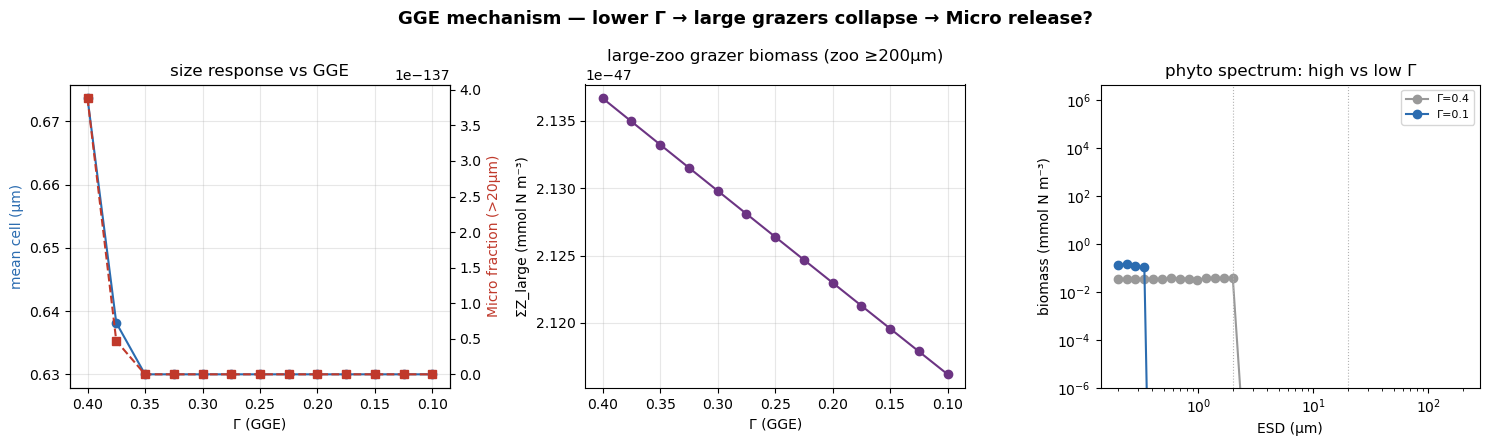

    Γ    mcs  microF    ΣZ≥200
 0.40   0.67   0.000  2.14e-47
 0.38   0.64   0.000  2.13e-47
 0.35   0.63   0.000  2.13e-47
 0.33   0.63   0.000  2.13e-47
 0.30   0.63   0.000  2.13e-47
 0.28   0.63   0.000  2.13e-47
 0.25   0.63   0.000  2.13e-47
 0.22   0.63   0.000  2.12e-47
 0.20   0.63   0.000  2.12e-47
 0.17   0.63   0.000  2.12e-47
 0.15   0.63   0.000  2.12e-47
 0.12   0.63   0.000  2.12e-47
 0.10   0.63   0.000  2.12e-47


In [16]:
# ── Cell — GGE mechanism: lower Γ → large-zoo grazers collapse → Micro release ─
res = 40                                                   # flip to 3 to see it at functional-group resolution
s   = SET[res]; esd = s['esd']; zoo = s['zoo']
g_seq = np.linspace(0.40, 0.10, 13)
rows, spec = [], {}
for g in g_seq:
    out = pu.run_single_point(cbs.model_baseline, s['setup'], {},
                              fixed_overrides={'Inflow__FN':FN_GGE,'Inflow__de':DE,'Grazing__gamma':g})
    P = out['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1)
    Z = out['Zooplankton__biomass'].values[:, -TAIL:].mean(axis=1)
    proc = pu.process_regime_run(out, esd, zoo, bin_defs, tail_len=TAIL)
    rows.append((g, np.nanmedian(proc['mcs_tail']), P[esd>=20].sum()/P.sum(), Z[zoo>=200].sum()))
    spec[round(g,2)] = P.copy()
rows = np.array(rows)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].plot(rows[:,0], rows[:,1], 'o-', color='#2b6cb0'); ax[0].set_ylabel('mean cell (µm)', color='#2b6cb0')
a0b = ax[0].twinx(); a0b.plot(rows[:,0], rows[:,2], 's--', color='#c0392b'); a0b.set_ylabel('Micro fraction (>20µm)', color='#c0392b')
ax[0].set(title='size response vs GGE', xlabel='Γ (GGE)'); ax[0].invert_xaxis()
ax[1].plot(rows[:,0], rows[:,3], 'o-', color='#6c3483'); ax[1].invert_xaxis(); ax[1].grid(alpha=0.3)
ax[1].set(title='large-zoo grazer biomass (zoo ≥200µm)', xlabel='Γ (GGE)', ylabel='ΣZ_large (mmol N m⁻³)')
gh, gl = round(g_seq[0],2), round(g_seq[-1],2)
ax[2].plot(esd, spec[gh], 'o-', color='0.6', label=f'Γ={gh}')
ax[2].plot(esd, spec[gl], 'o-', color='#2b6cb0', label=f'Γ={gl}')
for b in (2.0, 20.0): ax[2].axvline(b, ls=':', color='0.7', lw=0.8)
ax[2].set(xscale='log', yscale='log', title='phyto spectrum: high vs low Γ', xlabel='ESD (µm)',
          ylabel='biomass (mmol N m⁻³)', ylim=(1e-6, None)); ax[2].legend(fontsize=8)
ax[0].grid(alpha=0.3)
fig.suptitle('GGE mechanism — lower Γ → large grazers collapse → Micro release?', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

print(f"{'Γ':>5s} {'mcs':>6s} {'microF':>7s} {'ΣZ≥200':>9s}")
for r in rows: print(f"{r[0]:5.2f} {r[1]:6.2f} {r[2]:7.3f} {r[3]:9.3g}")

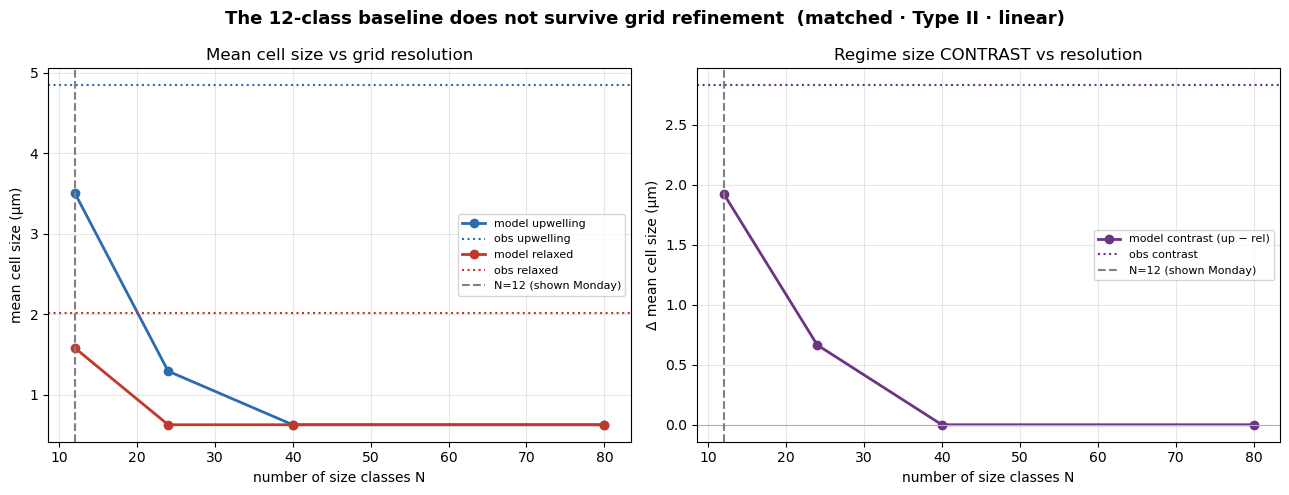

In [17]:
# ── Cell — SHOW-DON'T-TELL: the 12-class regime contrast doesn't survive refinement ──
def _setup(N):
    esd = np.logspace(np.log10(0.5), np.log10(200.0), N); z = cbs.ZOO_PHYTO_RATIO*esd
    iv = {
        'Nutrient':{'value_label':'N','value_init':cbs.N_INIT},
        'Phytoplankton':{'biomass_label':'P','biomass_init':np.full(N,cbs.P_INIT),
                         'phyto_esd_index':esd.tolist(),'phyto_esd_label':'phyto_esd'},
        'Zooplankton':{'biomass_label':'Z','biomass_init':np.full(N,cbs.Z_INIT),
                       'zoo_esd_index':z.tolist(),'zoo_esd_label':'zoo_esd'},
        'Inflow':{'var':'N','FN':cbs.FN_DEFAULT,'de':cbs.DE_DEFAULT,'de_label':'de'},
        'Growth':{'resource':'N','consumer':'P','mu_max':mu_taniguchi(esd),'halfsat':ks_t(esd)},
        'Grazing':{'phyto':'P','zoo':'Z','nutrient':'N','Imax':imax_t(z),'KsZ':ksz_t(z),'gamma':cbs.GAMMA_VAL},
        'PhytoLoss':{'population':'P','nutrient':'N','rate':np.full(N,cbs.LAMBDA_VAL)},
        'ZooLoss':{'population':'Z','nutrient':'N','rate':np.full(N,cbs.DELTA_VAL)},
        'PhytoSinking':{'population':'P','w_sink':cbs.W_SINK,'de':'de'},
    }
    return xso.setup(solver='solve_ivp', model=cbs.model_baseline, time=cbs.ivp_time_array,
                     input_vars=iv, solver_kwargs=cbs.IVP_SOLVER_KWARGS), esd, z

N_list = [12, 24, 40, 80]
mcs = {r: [] for r in regimes}
for N in N_list:
    st, esd, z = _setup(N)
    for r in regimes:
        out  = pu.run_single_point(cbs.model_baseline, st, {}, fixed_overrides=targets[r]['forcing'])
        proc = pu.process_regime_run(out, esd, z, bin_defs, tail_len=TAIL)
        mcs[r].append(np.nanmedian(proc['mcs_tail']))
obs_mcs = {r: np.nanmedian(pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)['mcs']) for r in regimes}

fig, ax = plt.subplots(1, 2, figsize=(13, 5)); COL = {'upwelling':'#2b6cb0','relaxed':'#c0392b'}
for r in regimes:
    ax[0].plot(N_list, mcs[r], 'o-', lw=2, color=COL[r], label=f'model {r}')
    ax[0].axhline(obs_mcs[r], ls=':', color=COL[r], lw=1.5, label=f'obs {r}')
ax[0].axvline(12, ls='--', color='0.5', label='N=12 (shown Monday)')
ax[0].set(title='Mean cell size vs grid resolution', xlabel='number of size classes N', ylabel='mean cell size (µm)')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

model_c = np.array(mcs['upwelling']) - np.array(mcs['relaxed'])
obs_c   = obs_mcs['upwelling'] - obs_mcs['relaxed']
ax[1].plot(N_list, model_c, 'o-', lw=2, color='#6c3483', label='model contrast (up − rel)')
ax[1].axhline(obs_c, ls=':', color='#6c3483', lw=1.5, label='obs contrast')
ax[1].axhline(0, color='0.7', lw=0.8); ax[1].axvline(12, ls='--', color='0.5', label='N=12 (shown Monday)')
ax[1].set(title='Regime size CONTRAST vs resolution', xlabel='number of size classes N', ylabel='Δ mean cell size (µm)')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
fig.suptitle('The 12-class baseline does not survive grid refinement  (matched · Type II · linear)',
             fontsize=13, weight='bold'); plt.tight_layout(); plt.show()

upwelling   CV(ΣP)=0.29   model mcs=3.51 µm   obs mcs=4.84 µm
relaxed     CV(ΣP)=0.08   model mcs=1.58 µm   obs mcs=2.01 µm


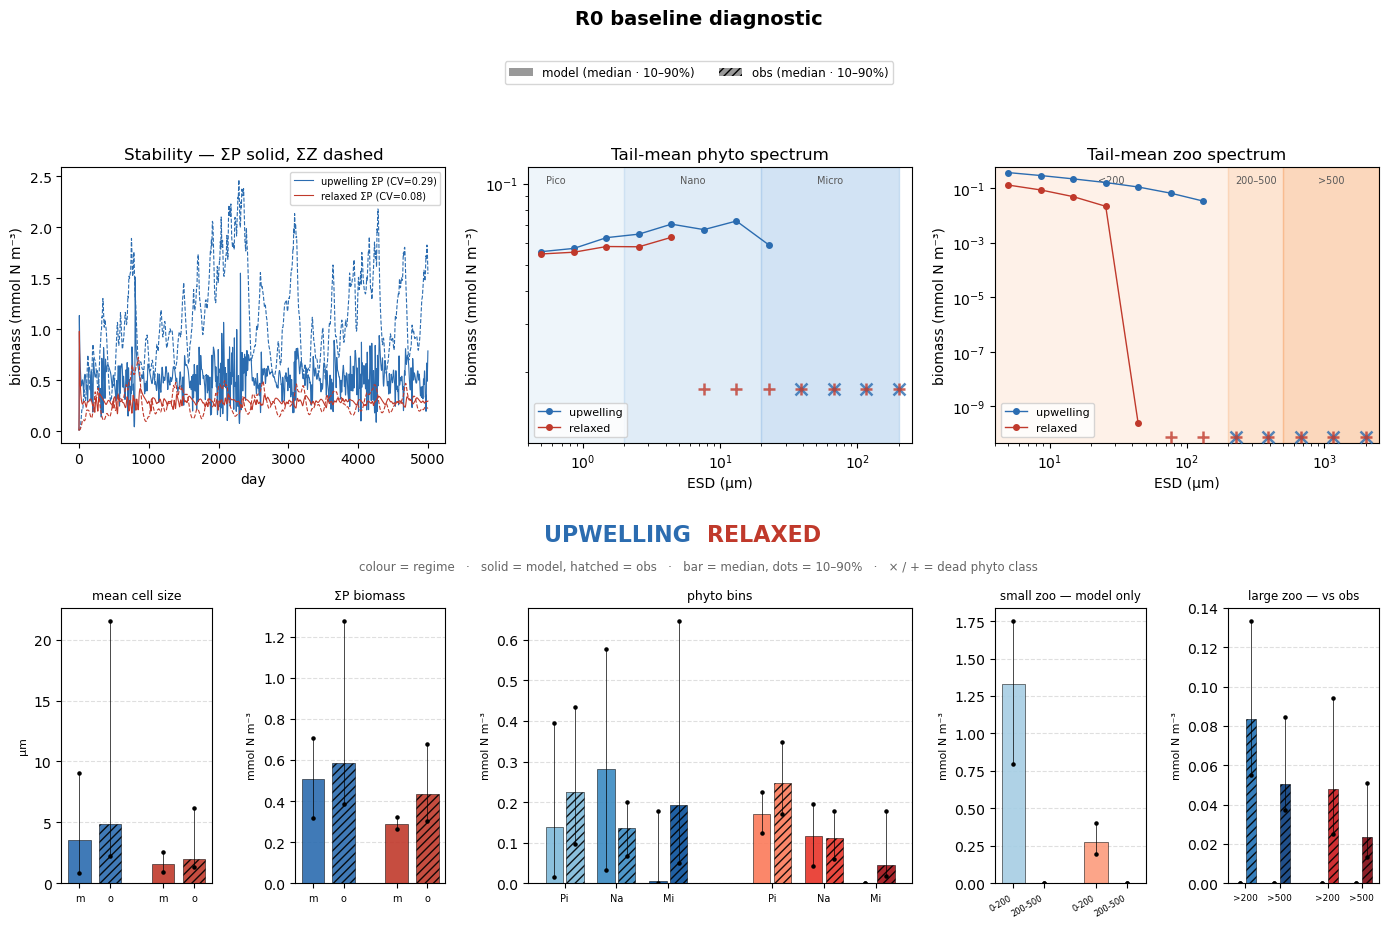

In [5]:
# ── Cell 5 — IVP runs per regime → tail-mean diagnostic vs obs (Fig 4) ───────
TAIL = 1000

model_by_regime, obs_by_regime = {}, {}
for r in regimes:
    out = pu.run_single_point(cbs.model_baseline, cbs.model_setup_baseline,
                              scan_params={}, fixed_overrides=targets[r]['forcing'])
    model_by_regime[r] = pu.process_regime_run(out, phyto_esd, zoo_esd, bin_defs,
                                               tail_len=TAIL)
    obs_by_regime[r]   = pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)
    print(f"{r:10s}  CV(ΣP)={model_by_regime[r]['cv']:.2f}   "
          f"model mcs={np.nanmedian(model_by_regime[r]['mcs_tail']):.2f} µm   "
          f"obs mcs={np.nanmedian(obs_by_regime[r]['mcs']):.2f} µm")

fig = pp.plot_regime_diagnostic(model_by_regime, obs_by_regime,
                                phyto_esd, zoo_esd, regimes=regimes)
plt.show()

In [6]:
# ── Cell 7 — stability analysis: fsolve steady state + eigenvalues, seeded ───
from xso.parscans import StabilityAnalysisHook

def tail_mean_seed(out, avg_window=TAIL):
    """Flat init-slot overrides = tail-mean state of an IVP run (the fsolve seed).
    Clipped positive so Newton doesn't stall on zeros/negatives."""
    return {
        'Nutrient__value_init': float(out['Nutrient__value'].values[-avg_window:].mean()),
        'Phytoplankton__biomass_init': np.maximum(
            out['Phytoplankton__biomass'].values[:, -avg_window:].mean(axis=1), 1e-9),
        'Zooplankton__biomass_init': np.maximum(
            out['Zooplankton__biomass'].values[:, -avg_window:].mean(axis=1), 1e-9),
    }

def run_stability(model, stab_setup, forcing, seed):
    """fsolve steady state + eigenvalues at one forcing, from a given seed."""
    hook = StabilityAnalysisHook()
    with model:
        out = (stab_setup.xsimlab
               .update_vars(input_vars={**forcing, **seed})
               .xsimlab.run(hooks=[hook]))
    return out, hook.get_results()

stab_by_regime = {}
for r in regimes:
    ivp = pu.run_single_point(cbs.model_baseline, cbs.model_setup_baseline,
                              scan_params={}, fixed_overrides=targets[r]['forcing'])
    out_s, s = run_stability(cbs.model_baseline, cbs.model_setup_baseline_stability,
                             targets[r]['forcing'], tail_mean_seed(ivp))
    stab_by_regime[r] = dict(
        stab=s,
        P_ss=out_s['Phytoplankton__biomass'].isel(time=-1).values,
        Z_ss=out_s['Zooplankton__biomass'].isel(time=-1).values,
        P_tail=ivp['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1),
        Z_tail=ivp['Zooplankton__biomass'].values[:, -TAIL:].mean(axis=1))
    print(f"{r:10s}  {s['stability']:9s}  max Re(λ)={s['max_eigenvalue_real']:+.4f}  "
          f"n_pos={s['n_positive_eigenvalues']}  n_complex_pairs={s['n_complex_pairs']}  "
          f"ΣP_ss={stab_by_regime[r]['P_ss'].sum():.3f}")

# IC robustness — same forcing, different fsolve seeds → same ecological state?
print("\nIC robustness (relaxed):")
ivp = pu.run_single_point(cbs.model_baseline, cbs.model_setup_baseline,
                          scan_params={}, fixed_overrides=targets['relaxed']['forcing'])
base = tail_mean_seed(ivp)
seeds = {
    'tail-mean':      base,
    'tail-mean x0.5': {k: v * 0.5 for k, v in base.items()},
    'tail-mean x2':   {k: v * 2.0 for k, v in base.items()},
    'uniform 0.1':    {'Nutrient__value_init': 1.0,
                       'Phytoplankton__biomass_init': np.full(cbs.N_CLASSES, 0.1),
                       'Zooplankton__biomass_init':   np.full(cbs.N_CLASSES, 0.1)},
}
for name, sd in seeds.items():
    _, s = run_stability(cbs.model_baseline, cbs.model_setup_baseline_stability,
                         targets['relaxed']['forcing'], sd)
    print(f"  {name:16s}  {s['stability']:9s}  max Re(λ)={s['max_eigenvalue_real']:+.4f}  "
          f"n_pos={s['n_positive_eigenvalues']}")

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 1.3492e-02
upwelling   unstable   max Re(λ)=+0.0135  n_pos=13  n_complex_pairs=8  ΣP_ss=0.516
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 2.3405e-03
relaxed     unstable   max Re(λ)=+0.0023  n_pos=7  n_complex_pairs=4  ΣP_ss=0.290

IC robustness (relaxed):
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 2.3405e-03
  tail-mean         unstable   max Re(λ)=+0.0023  n_pos=7
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 2.3405e-03
  tail-mean x0.5    unstable   max Re(λ)=+0.0023  n_pos=7
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] Syst

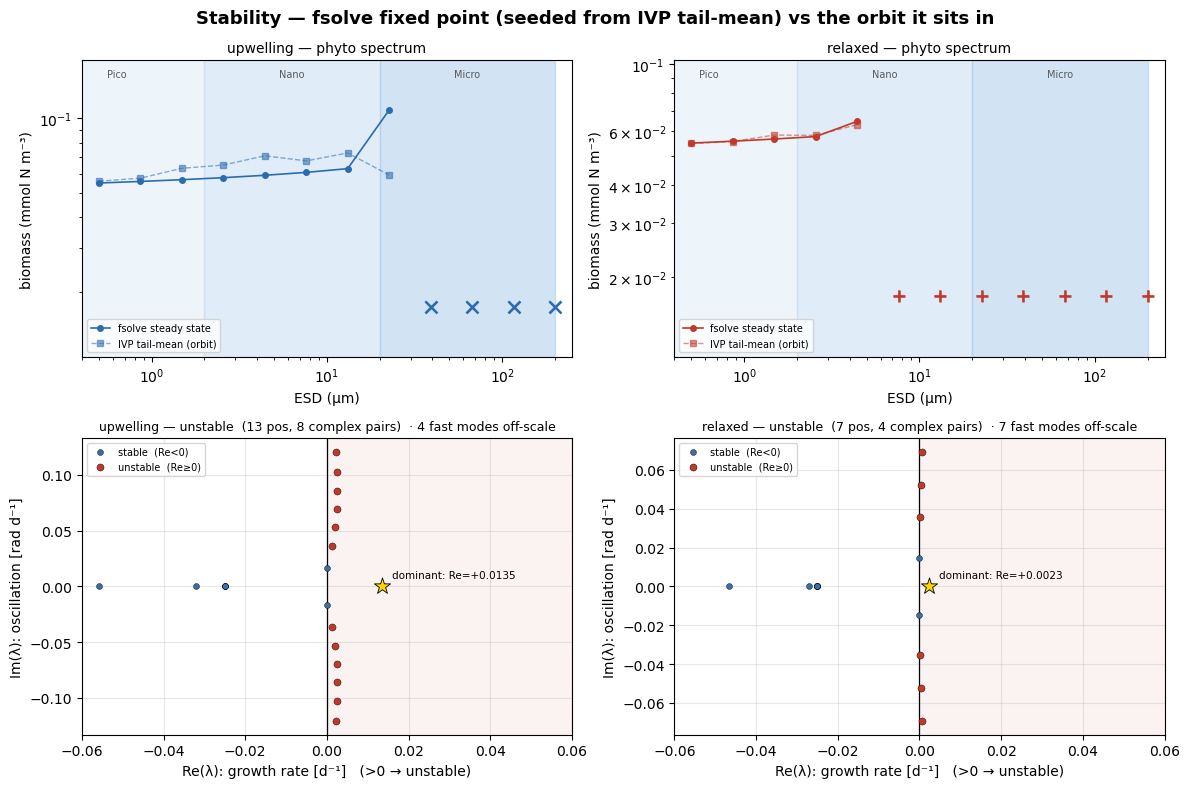

In [7]:
# ── Cell 8 — Fig 6: stability diagnostic (focus vs orbit + eigenvalues) ──────
fig = pp.plot_stability_diagnostic(stab_by_regime, phyto_esd, regimes=regimes)
plt.show()

In [8]:
# ── Cell 9 — consolidated text summary (paste this back to share results) ────
_ = pu.report_regime_diagnostic(
        model_by_regime, obs_by_regime, regimes=regimes,
        forcing_by_regime={r: targets[r]['forcing'] for r in regimes},
        stab_by_regime=stab_by_regime)

=== UPWELLING   (F_N=2.58, d_e=42.8) ===
                       model       obs     m/o
  mean cell um         3.509     4.841    0.72
  sumP mmolN/m3        0.509     0.583    0.87
  Pico frac            0.325     0.406    0.80
  Nano frac            0.663     0.248    2.68
  Micro frac           0.012     0.347    0.03
  zoo gt200            0.000     0.083    0.00
  zoo gt500            0.000     0.051    0.00
  CV(sumP)             0.294
  stability         unstable   max Re(lam)=+0.0135  13 pos, 8 pairs

=== RELAXED   (F_N=1.45, d_e=52.7) ===
                       model       obs     m/o
  mean cell um         1.585     2.013    0.79
  sumP mmolN/m3        0.289     0.436    0.66
  Pico frac            0.596     0.611    0.97
  Nano frac            0.404     0.275    1.47
  Micro frac           0.000     0.114    0.00
  zoo gt200            0.000     0.048    0.00
  zoo gt500            0.000     0.023    0.00
  CV(sumP)             0.077
  stability         unstable   max Re(lam

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'model_setup_baseline_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...
1D Scan complete. Time taken: 8.14338 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_t3' and setup 'model_setup_baseline_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...
1D Scan complete. Time taken: 10.39597 seconds.


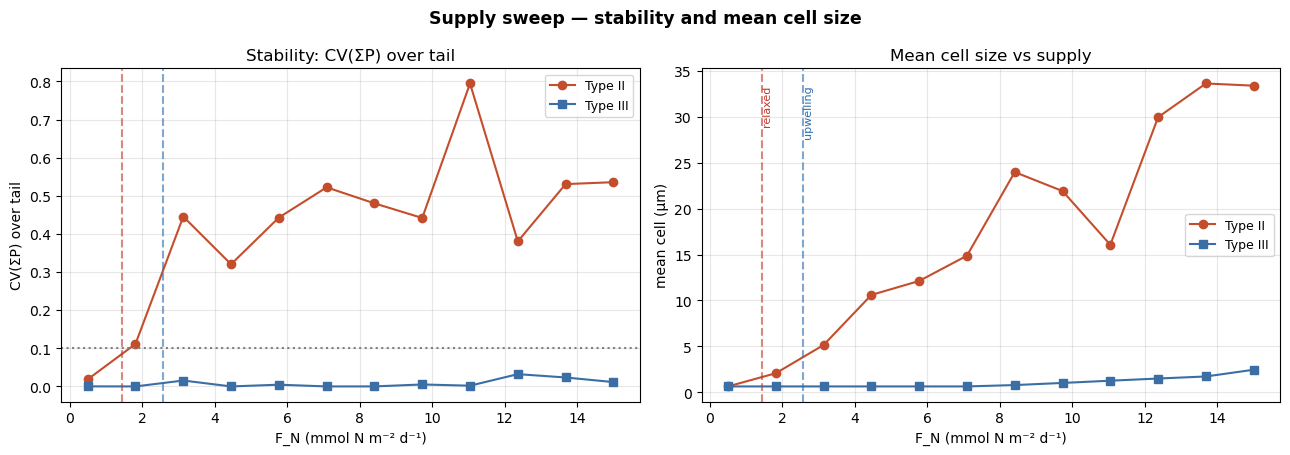

 F_N    CV_II  CV_III   mcs_II  mcs_III
 0.50   0.02    0.00     0.63     0.63
 1.82   0.11    0.00     2.07     0.63
 3.14   0.45    0.02     5.14     0.63
 4.45   0.32    0.00    10.60     0.63
 5.77   0.44    0.00    12.12     0.63
 7.09   0.52    0.00    14.87     0.63
 8.41   0.48    0.00    23.97     0.78
 9.73   0.44    0.01    21.91     1.01
11.05   0.79    0.00    16.06     1.25
12.36   0.38    0.03    29.96     1.49
13.68   0.53    0.02    33.63     1.72
15.00   0.54    0.01    33.39     2.45


In [9]:
# ── Cell 6 — supply sweep (Type II vs III): IVP CV + mean cell size vs F_N ────
fn_values = np.linspace(0.5, 15.0, 12)
DE_SWEEP  = cbs.DE_DEFAULT          # hold box depth fixed; sweep supply only

variant_setups = {
    'Type II':  ('model_baseline',    'model_setup_baseline_slim'),
    'Type III': ('model_baseline_t3', 'model_setup_baseline_t3_slim'),
}

sweep = {}
for label, (mname, sname) in variant_setups.items():
    res = run_xso_parscan(
        model_file_name='cariaco_baseline_setups',
        model_name=mname, model_setup_name=sname,
        param_name='Inflow__FN', param_values=fn_values,
        processes=8, fixed_overrides={'Inflow__de': DE_SWEEP},
    )
    cv, mcs = [], []
    for k in range(len(fn_values)):
        proc = pu.process_regime_run(res.isel({'Inflow__FN': k}),
                                     phyto_esd, zoo_esd, bin_defs, tail_len=TAIL)
        cv.append(proc['cv'])
        mcs.append(np.nanmedian(proc['mcs_tail']))
    sweep[label] = {'cv': np.array(cv), 'mean_cell': np.array(mcs)}

regime_fn = {r: targets[r]['forcing']['Inflow__FN'] for r in regimes}
fig = pp.plot_stability_scan(sweep, fn_values, regime_fn=regime_fn,
                             metric_key='cv', metric_label='CV(ΣP) over tail',
                             metric_threshold=0.1)
plt.show()

print(" F_N    CV_II  CV_III   mcs_II  mcs_III")
for k, fn in enumerate(fn_values):
    print(f"{fn:5.2f}  {sweep['Type II']['cv'][k]:5.2f}  "
          f"{sweep['Type III']['cv'][k]:6.2f}   "
          f"{sweep['Type II']['mean_cell'][k]:6.2f}  "
          f"{sweep['Type III']['mean_cell'][k]:7.2f}")